# Predicting the success of bank telemarketing, in time order

`bank-additional-full.csv` (UCI, 41.188 contacts, May 2008 - November 2010) is **ordered in
time**, and its statistics move: the subscription rate goes from 3% over the first months
to 45% over the last ones. This notebook asks what the results on this dataset become
once the validation respects that order instead of training on random splits, and whether the five macro socio-economic features help or hurt (or do not matter) once it does.

The motivation, the comparison with the source paper (Moro, Cortez & Rita, 2014) and the
headline numbers are in the **[README](README.md)**.

## 1. Import necessary packages


In [1]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_curve, roc_auc_score,
                             average_precision_score)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     TimeSeriesSplit)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

## 2. Load the dataset and define features and objective sets.


In [2]:

#Load dataset and rename target column
df = pd.read_csv("bank-additional-full.csv", delimiter=";")
df.rename(columns={'y': "deposit"}, inplace=True)

#Definition of features categories

#The five macro socio-economic features
ECONOMIC = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
#Numerical features
NUMERICAL = ["age", "campaign", "pdays", "previous","duration"] + ECONOMIC
#Categorical features
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "day_of_week", "poutcome"]
#All features
FEATURES = NUMERICAL + CATEGORICAL

#Target feature: whether the client subscribed a long-term deposit contract
TARGET = "deposit"

## 3. EDA

### 3.1 Data cleaning
In this case the dataset is widely used, so it would be safe to assume that it is clean. However, it is a good practice never to skip this step.

We refer to `bank-additional-names.txt` for the details on the dataset. The raw dataset has 41.188 rows and 20 features (+ 1 target).

We describe each feature to better understand the setting. Every feature describes either the client or the call itself; none describes the bank side (the paper's dataset also had the agent's experience, the rate offered and the client's relationship with the bank). We shortly describe them when their name is not self-explanatory.

- **"age"**: (Numerical).
- **"job"**: (Categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown").
- **"marital"**: (Categorical: "divorced","married","single","unknown").
- **"education"**: (Categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown").
- **"default"**: Has default credit? (Binary: "yes", "no", "unknown").
- **"housing"**: Has housing loan? (Categorical: "no","yes","unknown").
- **"loan"**: Has personal loan? (Categorical: "no","yes","unknown").
- **"contact"**: Contact communication type (Categorical: "cellular","telephone").
- **"month"**: Last contact month of year (Categorical: "jan", "feb", "mar", ..., "nov", "dec").
- **"day_of_week"**: Last contact day of the week (Categorical: "mon","tue","wed","thu","fri").
- **"duration"**: Last contact duration, in seconds (Numerical). **Important note**:  this attribute **highly** affects the output target (e.g., if duration=0 then y="no"). Yet, the **duration is not known before a call is performed**. Also, after the end of the call y is obviously known. Thus, **this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model**.
- **"campaign"** : Number of contacts performed during this campaign and for this client (Numerical).
- **"pdays"**: Number of days that passed by after the client was last contacted from a previous campaign (Numerical; 999 means client was not previously contacted).
- **"previous"**: Number of contacts performed before this campaign and for this client (Numerical).
- **"poutcome"**: Outcome of the previous marketing campaign (Categorical: "failure","nonexistent","success").
### social and economic context attributes
- **"emp.var.rate"**: Employment variation rate, quarterly indicator (Numerical).
- **"cons.price.idx"**: Consumer price index, monthly indicator (Numerical).
- **"cons.conf.idx"**: Consumer confidence index, monthly indicator (Numerical).
- **"euribor3m"**: Euribor 3 month rate,  daily indicator (Numerical).
- **"nr.employed"**: Number of employees, quarterly indicator (Numerical).
### target
- **"deposit"**: Has the client subscribed a term deposit? (Binary: "yes","no").

In [3]:
# Check the dimensions of the dataframe

ROWS = 41188
COLS = 21
if df.shape[0] != ROWS or df.shape[1] != COLS:
	warnings.warn("WARNING! Dataframe dimensions inconsistent with the documentation!")
else:
	print(f"The DataFrame has {ROWS} rows and {COLS} columns, as claimed in the documentation file.")

The DataFrame has 41188 rows and 21 columns, as claimed in the documentation file.


In [4]:
# Check for heterogeneous entries and missing values

expected = {c: "number" for c in NUMERICAL} | {c: "string" for c in CATEGORICAL}
wrong = [c for c, kind in expected.items()
         if (kind == "number") != pd.api.types.is_numeric_dtype(df[c])]
if wrong:
    warnings.warn(f"WARNING! : unexpected dtype in {wrong}")
else:
	print("No unexpected types\n")
s = df.isna().sum().sum()

if s >0:
	warnings.warn(f"WARNING! : There are {s} NaN values in the dataframe.")
else:
	print(f"No missing values.")


No unexpected types

No missing values.


We now check each feature separately to make sure that no incorrect values appear in the dataset.

In [5]:
#We check the values of categorical data vs the ones reported in the documentation .txt file. We issue a warning if the values
#appearing in the dataaset are not a subset of the possible values described in the documentation.
POSSIBLE_JOBS = {"admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired", "self-employed",
                 "services", "student", "technician", "unemployed", "unknown"}
if not set(df["job"].unique()).issubset(POSSIBLE_JOBS):
	warnings.warn("WARNING! : Job type is inconsistent")

POSSIBLE_MARITAL_STATUS = {"divorced", "married", "single", "unknown"}
if not set(df["marital"].unique()).issubset(POSSIBLE_MARITAL_STATUS):
	warnings.warn("WARNING! : Marital status is inconsistent")

EDUCATION = {"basic.4y", "basic.6y", "basic.9y", "high.school", "illiterate", "professional.course",
             "university.degree", "unknown"}
if not set(df["education"].unique()).issubset(EDUCATION):
	warnings.warn("WARNING! : Education is inconsistent")

POSSIBLE_DEFAULT = {"yes", "no", "unknown"}
if not set(df["default"].unique()).issubset(POSSIBLE_DEFAULT):
	warnings.warn("WARNING! : Default type is inconsistent")

POSSIBLE_HOUSING = {"yes", "no", "unknown"}
if not set(df["housing"].unique()).issubset(POSSIBLE_HOUSING):
	warnings.warn("WARNING! : Housing type is inconsistent")

POSSIBLE_LOAN = {"yes", "no", "unknown"}
if not set(df["loan"].unique()).issubset(POSSIBLE_LOAN):
	warnings.warn("WARNING! : Loan type is inconsistent")

POSSIBLE_CONTACT = {"cellular", "telephone"}
if not set(df["contact"].unique()).issubset(POSSIBLE_CONTACT):
	warnings.warn("WARNING! : Contact type is inconsistent")

POSSIBLE_MONTH = {"jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"}
if not set(df["month"].unique()).issubset(POSSIBLE_MONTH):
	warnings.warn("WARNING! : Month type is inconsistent")

POSSIBLE_DAY_OF_WEEK = {"mon", "tue", "wed", "thu", "fri"}
if not set(df["day_of_week"].unique()).issubset(POSSIBLE_DAY_OF_WEEK):
	warnings.warn("WARNING! : Day_of_week type is inconsistent")

POSSIBLE_POUTCOME = {"failure", "nonexistent", "success"}
if not set(df["poutcome"].unique()).issubset(POSSIBLE_POUTCOME):
	warnings.warn("WARNING! : Poutcome type is inconsistent")

#We check that the numerical features related to contacts are non-negative, with pdays additionally admitting the sentinel value 999.
if ((df["age"]<0) | (df["age"]>=130)).sum() >0:
	warnings.warn("WARNING! Age values are inconsistent")

elif (df["campaign"]<0).sum() >0:
	warnings.warn("WARNING! Campaign values are inconsistent")

elif ((df["pdays"]<0) | (df["pdays"]>999)).sum() >0:
	warnings.warn("WARNING! Pdays values are inconsistent")

elif (df["previous"]<0).sum() >0:
	warnings.warn("WARNING! Previous values are inconsistent")

elif (df["duration"]<0).sum() >0:
	warnings.warn("WARNING! Duration values are inconsistent")

else:
    print("All categorical and contact-related numerical features are consistent with the documentation.")


All categorical and contact-related numerical features are consistent with the documentation.


In [6]:
#Finally, we check the five social and economic context attributes and the target.

#These are quarterly/monthly/daily indicators, so we only check that they are finite numbers, without imposing hard bounds (unlike the other numerical features, there is no documented valid range for them).
if not np.isfinite(df[ECONOMIC]).all().all():
	warnings.warn("WARNING! : There are non-finite values among the economic/social features")

#euribor3m and nr.employed are, respectively, an interest rate and a headcount, so they must be strictly positive.
if (df["euribor3m"]<=0).sum() >0:
	warnings.warn("WARNING! Euribor3m values are inconsistent")

if (df["nr.employed"]<=0).sum() >0:
	warnings.warn("WARNING! Nr.employed values are inconsistent")

#Lastly, we check the target: the client either subscribed a deposit or did not.
POSSIBLE_DEPOSIT = {"yes", "no"}
if set(df[TARGET].tolist()) != POSSIBLE_DEPOSIT:
	warnings.warn("WARNING! : Deposit (target) type is inconsistent")
else:
	print("\nAll economic/social features are finite and consistent, and the target is binary as expected.")


All economic/social features are finite and consistent, and the target is binary as expected.


Now that we are sure the data is clean, we can start with the real EDA. We focus first on numerical features, and later on categorical ones.


### 3.2 EDA on numerical features

 The documentation states that **`pdays` = 999** means "the client was not previously contacted". We replace the flag value of 999 with a nan.

In [7]:
NO_PREV = 999 #placeholder in pdays
df.loc[df["pdays"] == NO_PREV, "pdays"] =np.nan

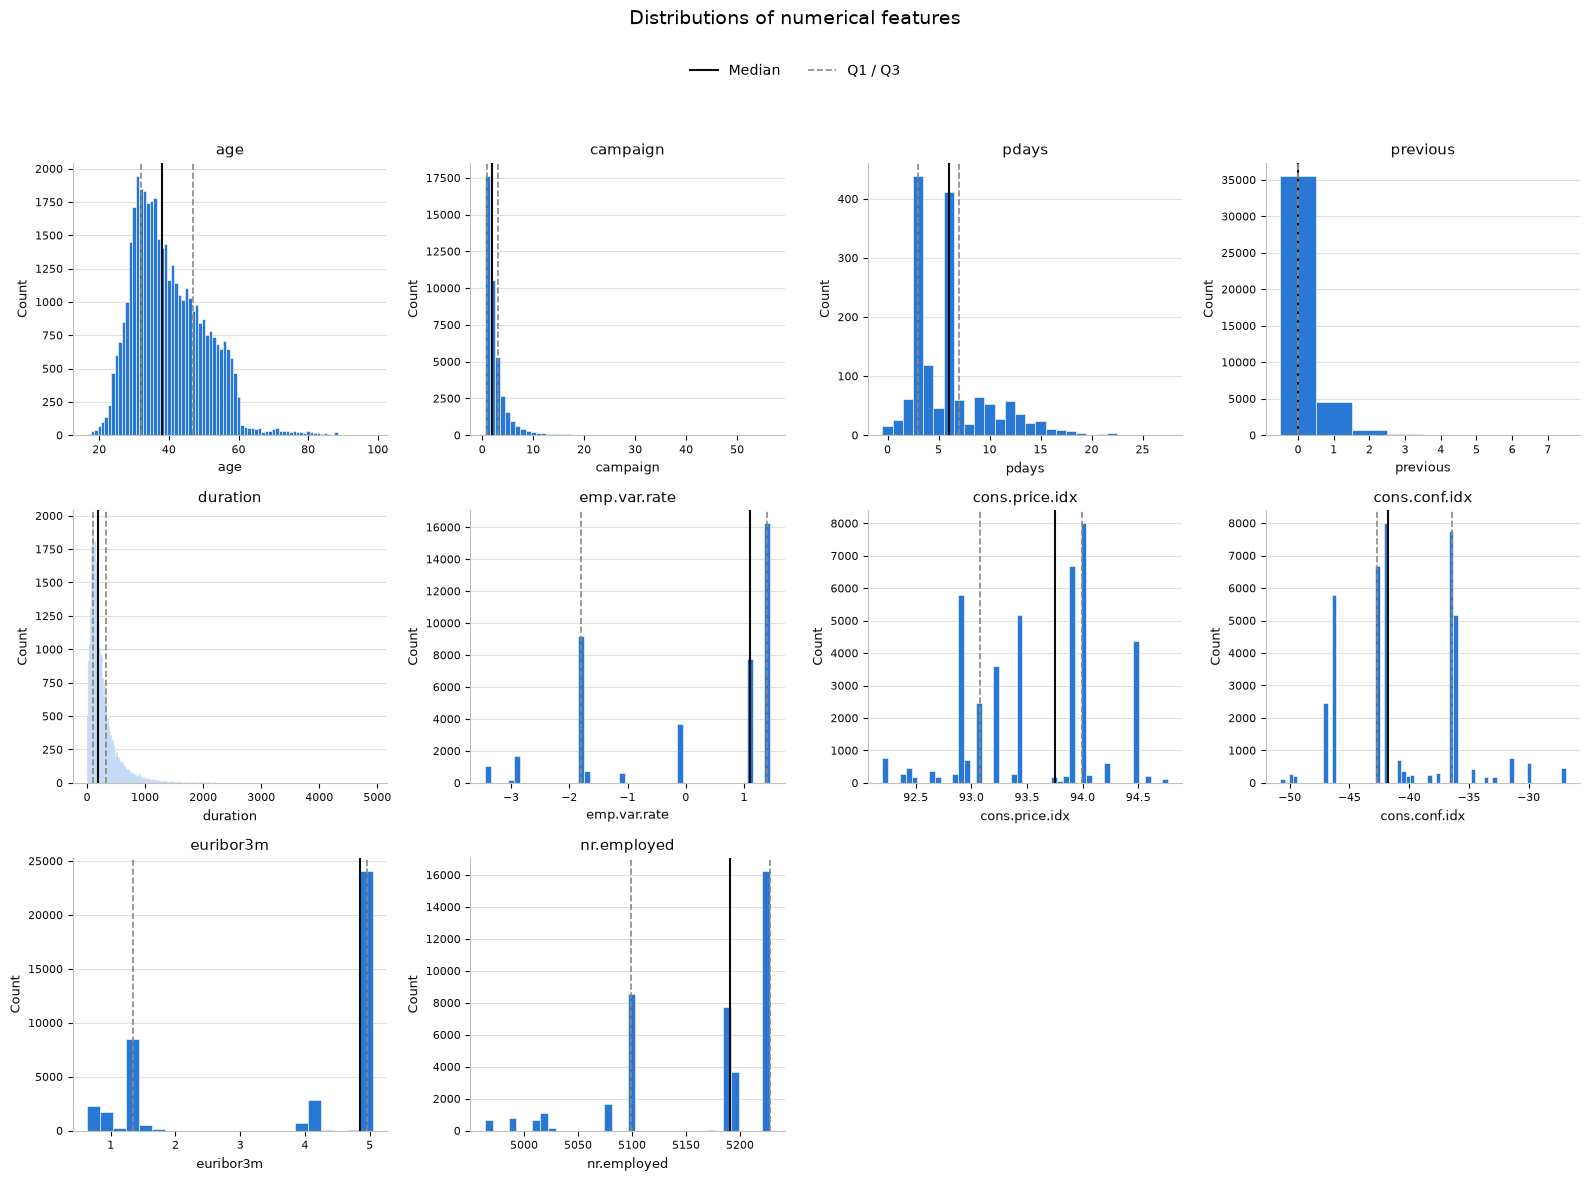

In [8]:
BAR_COLOR = "#2a78d6"       # single sequential hue for the bars
MEDIAN_COLOR = "#0b0b0b"    # primary ink
QUANTILE_COLOR = "#898781"  # muted ink
GRID_COLOR = "#e1e0d9"      # hairline gridline
AXIS_COLOR = "#c3c2b7"      # baseline/axis


def value_aligned_bins(values, max_bins=100, max_unique=250, rtol=1e-6):
    #Returns bin edges of constant width, each bin centred on one distinct value, when the distinct
    #values lie on a regular lattice (all gaps integer multiples of the smallest). The bin width is
    #that smallest gap; gaps in the lattice become empty bins.
    #Returns "auto" when the values are not on a lattice, when there are more than `max_unique`
    #distinct values, or when the lattice would need more than `max_bins` bins.
    uniques = np.unique(np.asarray(values, dtype=float))
    uniques = uniques[np.isfinite(uniques)]

    if uniques.size == 0:
        return "auto"
    if uniques.size == 1:
        return np.array([uniques[0] - 0.5, uniques[0] + 0.5])
    if uniques.size > max_unique:
        return "auto"

    gaps = np.diff(uniques)
    step = gaps.min()
    if step <= 0:
        return "auto"

    multiples = gaps / step
    if not np.allclose(multiples, np.round(multiples), rtol=rtol, atol=1e-9):
        return "auto"

    n_bins = int(round((uniques[-1] - uniques[0]) / step)) + 1
    if n_bins > max_bins:
        return "auto"

    return uniques[0] - step / 2 + step * np.arange(n_bins + 1)


n_rows = n_cols = int(np.ceil(np.sqrt(len(NUMERICAL))))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, NUMERICAL):
    data = df[col].dropna()
    bins = value_aligned_bins(data.values)
    ax.hist(data, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.4, zorder=2)

    q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
    ax.axvline(median, color=MEDIAN_COLOR, linestyle="-", linewidth=1.5, zorder=3, label="Median")
    ax.axvline(q1, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3, label="Q1 / Q3")
    ax.axvline(q3, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel(col, fontsize=9, color="#0b0b0b")
    ax.set_ylabel("Count", fontsize=9, color="#0b0b0b")
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

#Remove any unused axes (if the grid has more cells than features).
for ax in axes[len(NUMERICAL):]:
    fig.delaxes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.03), fontsize=10)
fig.suptitle("Distributions of numerical features", fontsize=14, y=1.06)
fig.tight_layout()
plt.show()

We learn a few things from a simple visual inspection of the data:
- The campaign mostly targets people between 30 and 40, with a sharp drop after 60.
- Most people are contacted either once or twice at most.
- When people are contacted again, this usually happens before a week.
- Most people in this campaign were never contacted by previous ones.

The economic and social features (i.e. the last five ones) are scattered and do not give any immediate insight.

We now consider the correlation between numerical features.

<Axes: >

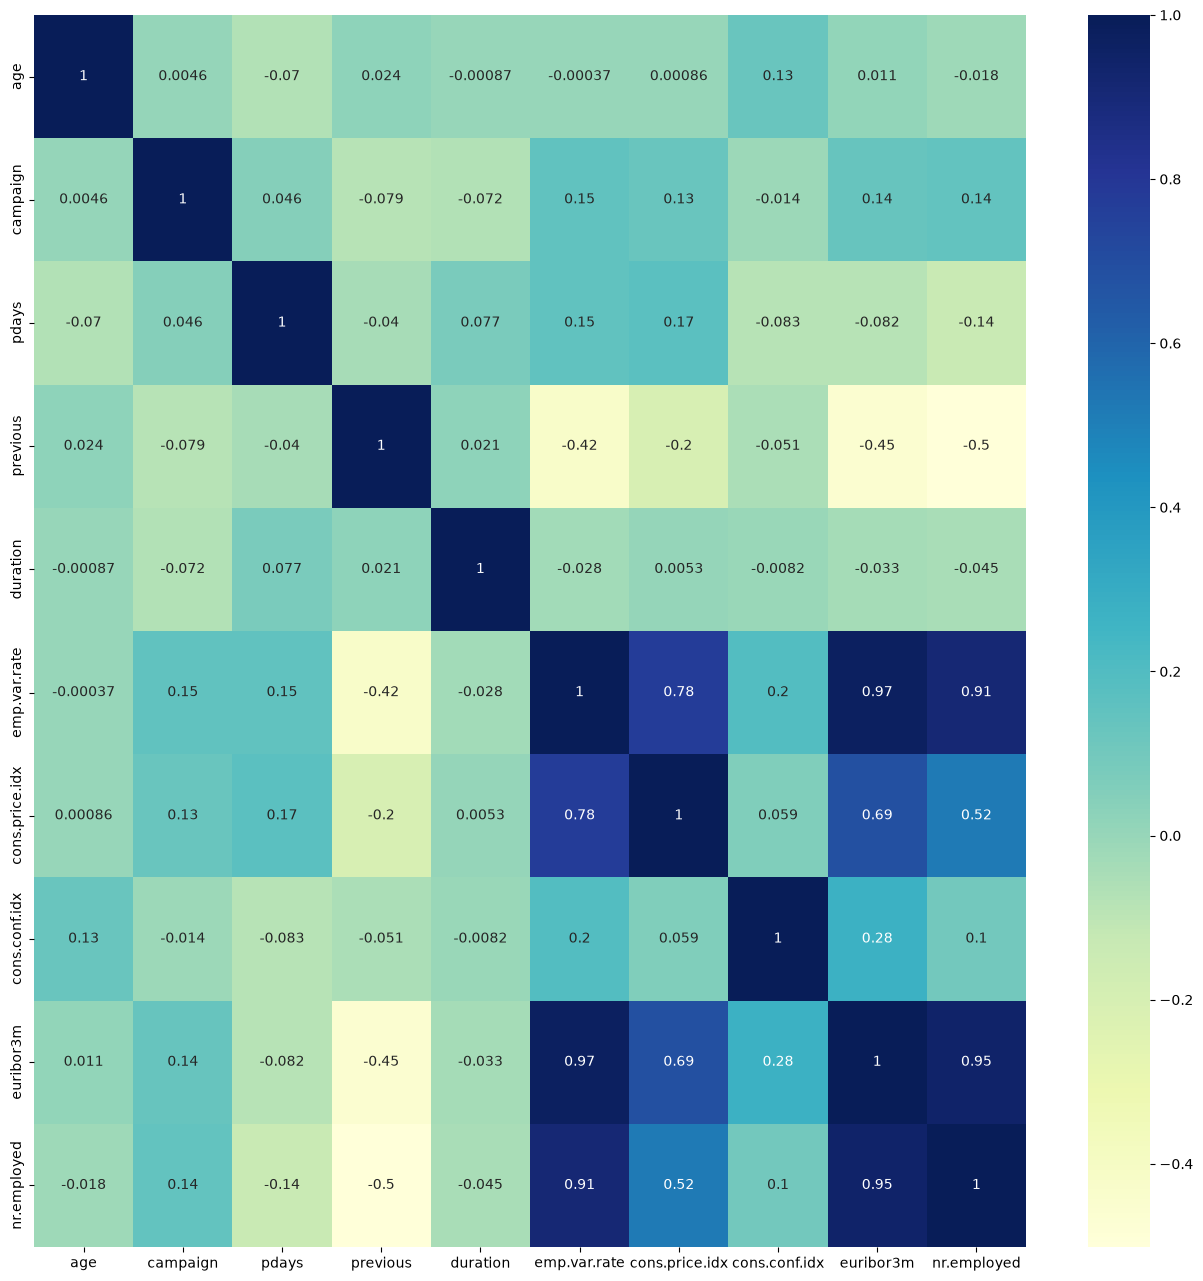

In [9]:
plt.figure(figsize=(16, 16))
sns.heatmap(df[NUMERICAL].corr(method='pearson', min_periods=1),cmap="YlGnBu",annot = True)

### 3.3 EDA on categorical features

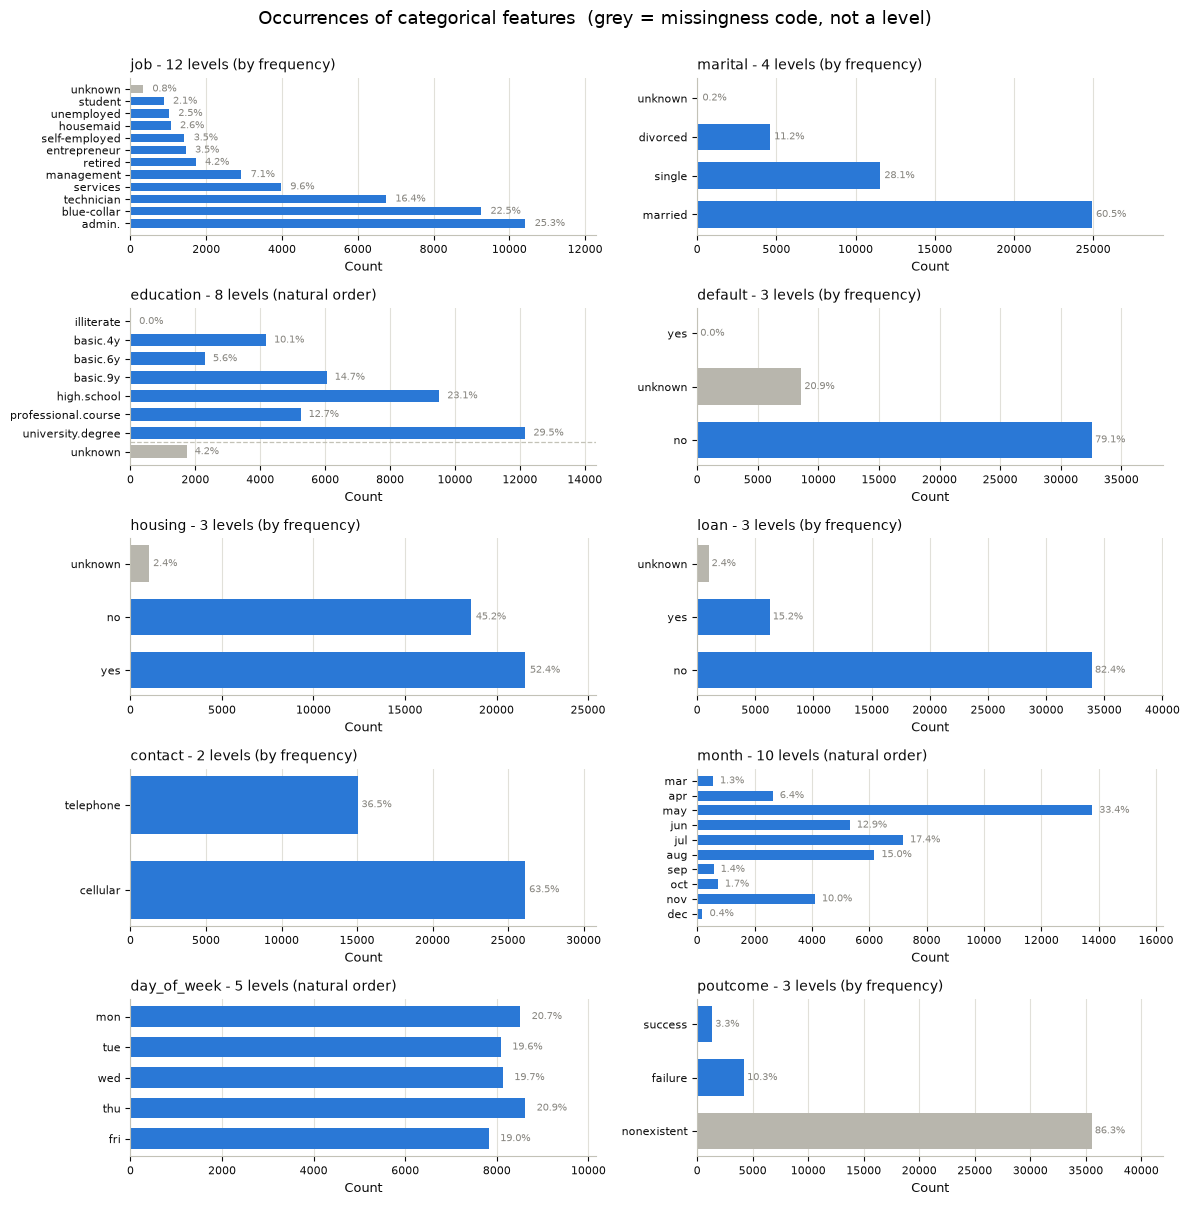

In [10]:
NATURAL_ORDER = {
    "education": ["illiterate", "basic.4y", "basic.6y", "basic.9y",
                  "high.school", "professional.course", "university.degree"],
    "month": ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
    "day_of_week": ["mon", "tue", "wed", "thu", "fri"],
}
NOT_A_LEVEL = {"unknown", "nonexistent"}
MISSING_COLOR = "#b8b6ad"

n_cols = 2
n_rows = int(np.ceil(len(CATEGORICAL) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 2.4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, CATEGORICAL):
    counts = df[col].value_counts()

    if col in NATURAL_ORDER:
        #Declared levels that occur, then everything else (missingness codes, or a level
        #I forgot to declare) appended so nothing can be silently dropped.
        order = [l for l in NATURAL_ORDER[col] if l in counts.index]
        order += [l for l in counts.index if l not in order]
        note = "natural order"
    else:
        order = list(counts.sort_values().index)
        note = "by frequency"

    order  = order[::-1]                     #reverse ONCE: barh draws index 0 at the bottom
    counts = counts.reindex(order)           #both counts and colours now follow `order`
    colors = [MISSING_COLOR if l in NOT_A_LEVEL else BAR_COLOR for l in order]

    ax.barh(counts.index.astype(str), counts.values, color=colors, height=0.68, zorder=2)
    for level, n in counts.items():
        ax.text(n + 0.006 * len(df), str(level), f"{100 * n / len(df):.1f}%",
                va="center", fontsize=7, color=QUANTILE_COLOR)

    #Separator between the ordinal scale and the codes that are not on it.
    n_missing = sum(l in NOT_A_LEVEL for l in order)
    if col in NATURAL_ORDER and n_missing:
        ax.axhline(n_missing - 0.5, color=AXIS_COLOR, lw=0.9, ls="--", zorder=1)

    ax.set_title(f"{col} - {len(counts)} levels ({note})", fontsize=10, loc="left", color="#0b0b0b")
    ax.set_xlabel("Count", fontsize=9, color="#0b0b0b")
    ax.set_xlim(0, counts.max() * 1.18)
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

for ax in axes[len(CATEGORICAL):]:
    fig.delaxes(ax)

fig.suptitle("Occurrences of categorical features  (grey = missingness code, not a level)",
             fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

### 3.4 Time dependent EDA

As we already mentioned, the dataset is implicitly **ordered with respect to time**. Thus, we now consider a EDA taking into account the fact that statistics may change with respect to time. By far, the strongest signal that time is a crucial feature in the model is the percentage of positive outcomes (i.e. of people signing a long-term deposit contract), averaged over a 1000 rows window.

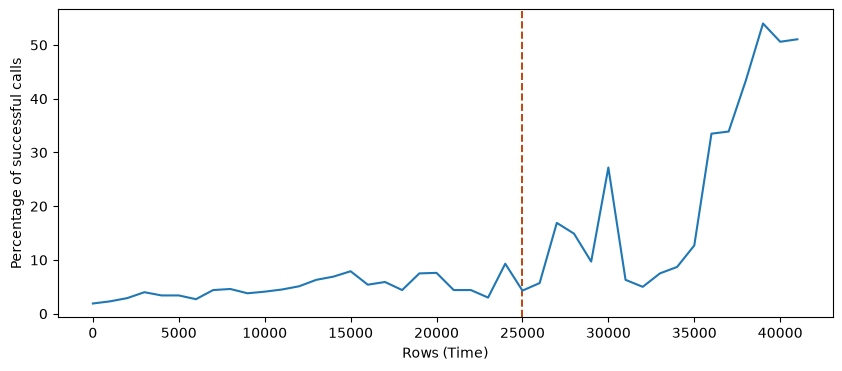

In [11]:
BLOCK = 1000
THRESHOLD = 25000
fig, ax = plt.subplots(figsize=(10, 4))
x, rate = [], []
for start in range(0, len(df), BLOCK) :
	block = df["deposit"][start : start + BLOCK]
	yes = (block == "yes").sum()
	tot = len(block)
	x.append(start)
	rate.append(100 * yes / tot)
ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4)
ax.set_xticks(x[: :5])
ax.set_xlabel("Rows (Time)")
ax.set_ylabel("Percentage of successful calls")
plt.plot(x, rate)
plt.show()

We now repeat this for every feature, reusing the same `BLOCK` size and the same 25.000-row threshold, to see whether individual numerical and categorical features drift over time as well, or whether the shift is confined to the subscription rate. We do not group **"months"** in blocks of size 1000 in order to show hw the dataset is ordered in time (from May 2008 to November 2010 in particular) and how data about the second half of 2008 dominates in the dataset, being more than half of it.

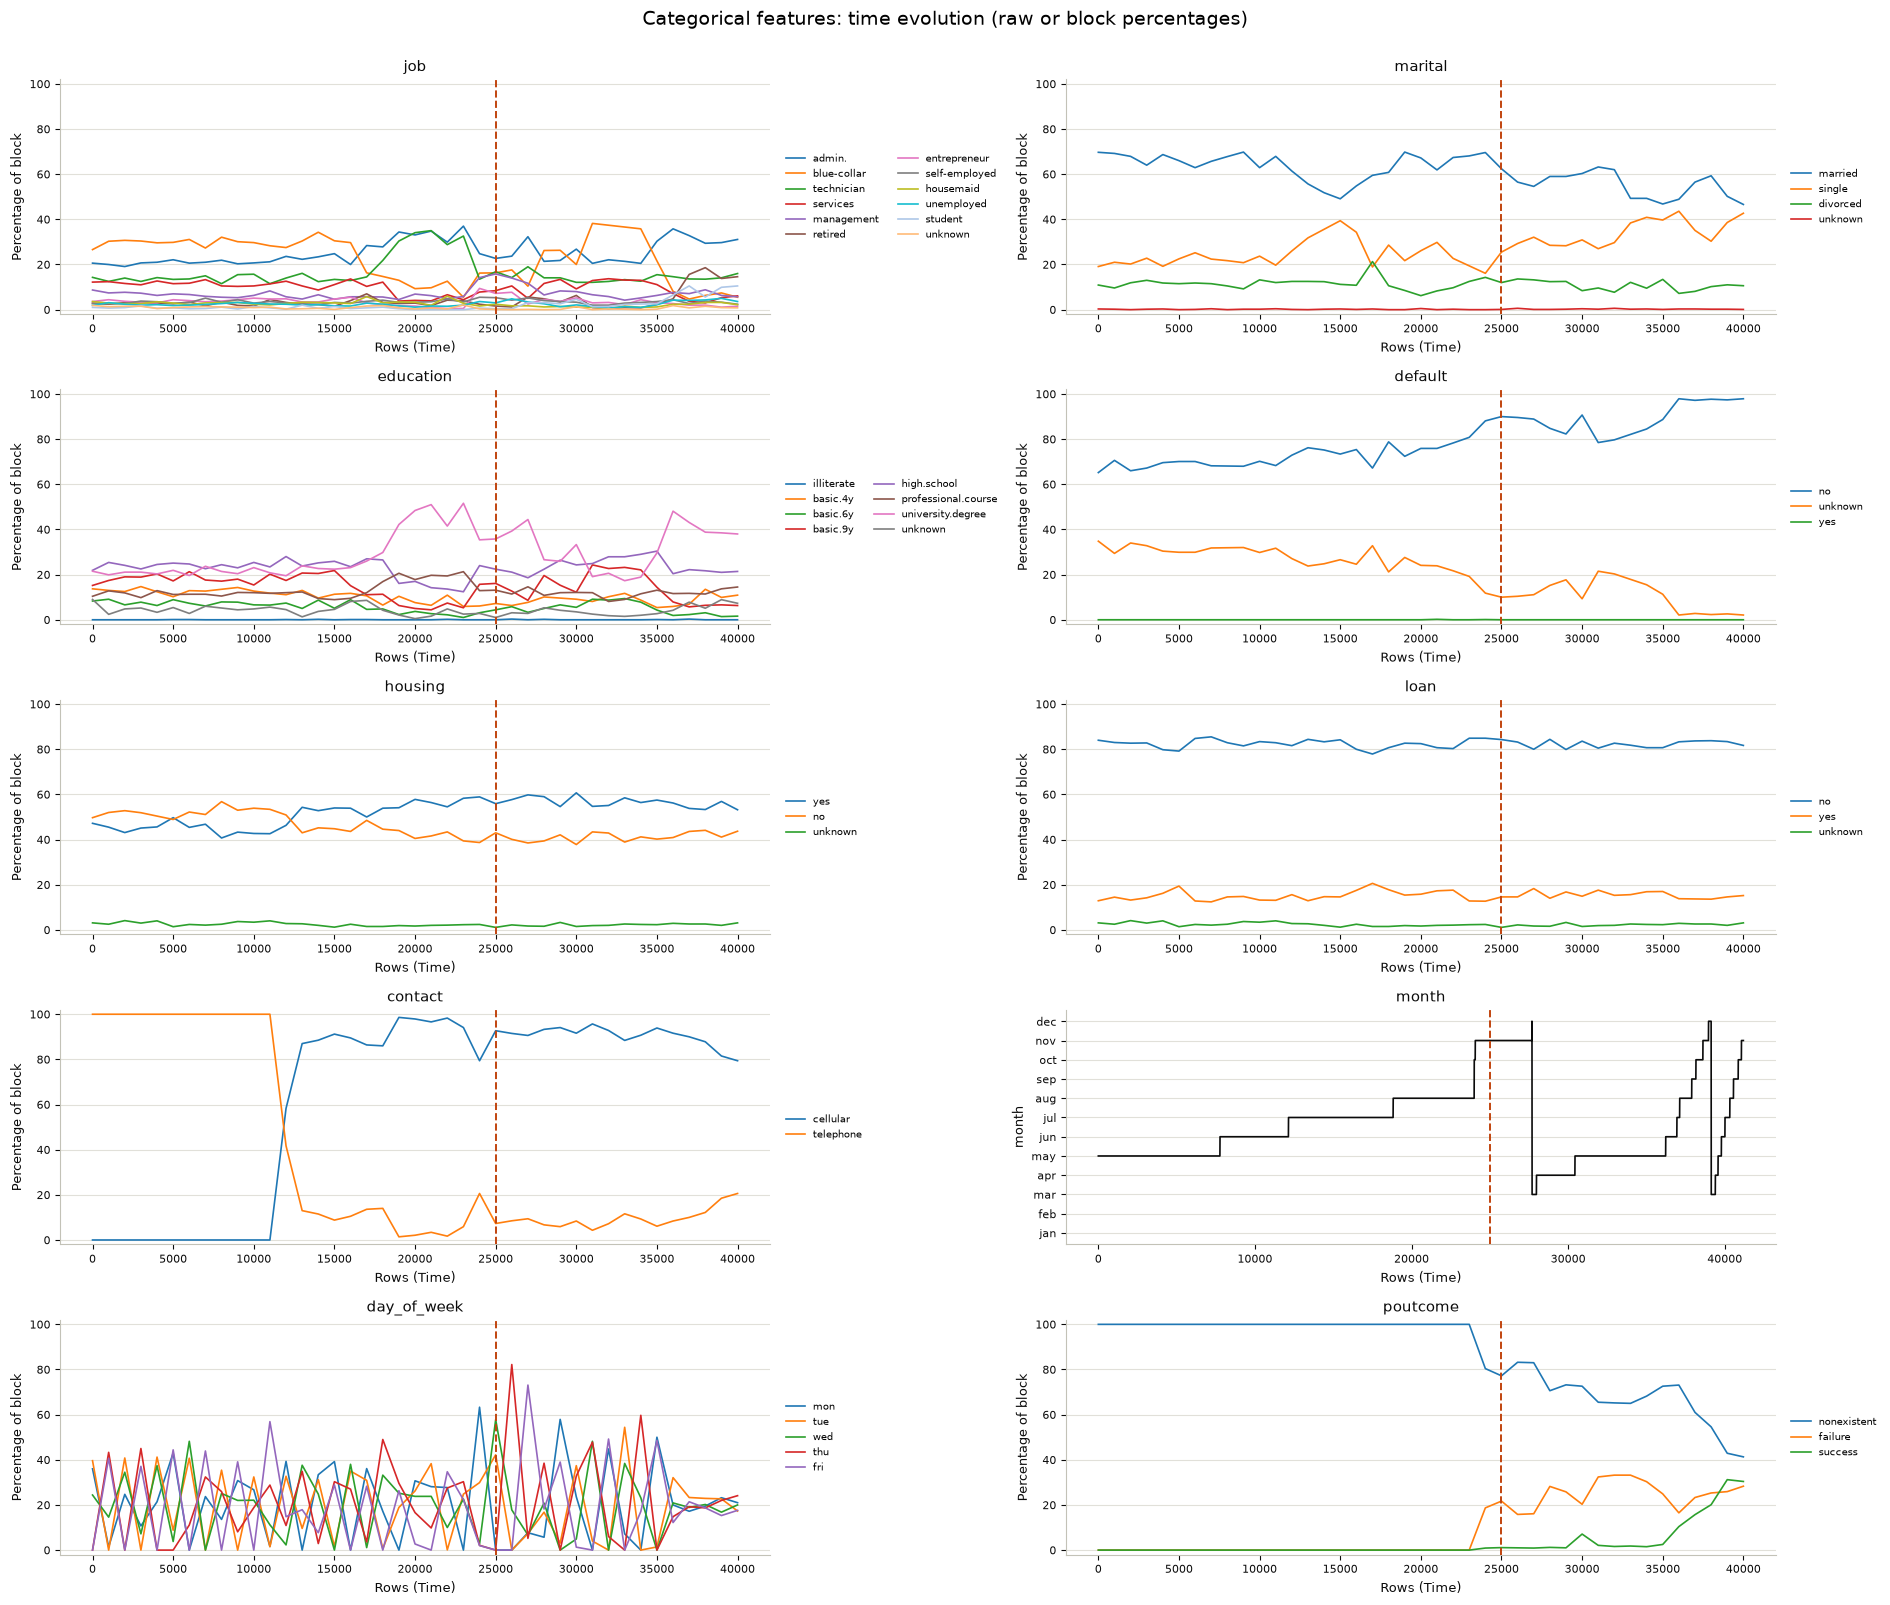

In [12]:
#For each categorical feature, we compute, per block of BLOCK rows, the percentage of rows
#falling in each level (i.e. the block-average of the one-hot indicator of that level).


NO_BLOCK_COLS = {"month"}  # Columns where we plot the vaues of each row, without grouping them beforehand

_t20 = plt.get_cmap("tab20").colors
PALETTE = list(_t20[0::2]) + list(_t20[1::2])

n_cols = 2
n_rows = int(np.ceil(len(CATEGORICAL) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9.5 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, CATEGORICAL):
    uniques = df[col].unique()
    #Case 1: No blocks
    if col in NO_BLOCK_COLS:
        if col == "month":
            MONTHS = ["jan", "feb", "mar", "apr", "may", "jun",
                      "jul", "aug", "sep", "oct", "nov", "dec"]
            mnum = df["month"].map({m: i for i, m in enumerate(MONTHS, 1)})

            ax.plot(np.arange(len(df)), mnum, lw=1.2, color="#0b0b0b")
            ax.set_yticks(range(1, 13))
            ax.set_yticklabels(MONTHS)
            ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
            ax.set_ylabel("month", fontsize=9, color="#0b0b0b")
            ax.set_ylim(0.4, 12.6)

            ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

            ax.set_title(col, fontsize=11, color="#0b0b0b")
            ax.tick_params(labelsize=8, colors="#0b0b0b")
            ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
            ax.set_axisbelow(True)
            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            for spine in ("left", "bottom"):
                ax.spines[spine].set_color(AXIS_COLOR)
            continue

    #Case 2: with blocks
    if col in NATURAL_ORDER:
        levels = [l for l in NATURAL_ORDER[col] if l in uniques]
        levels += [l for l in uniques if l not in levels]
    else:
        levels = list(df[col].value_counts().index)

    colors = [PALETTE[i % len(PALETTE)] for i in range(len(levels))]

    x = []
    pct = {lvl: [] for lvl in levels}
    for start in range(0, len(df), BLOCK):
        block = df[col].iloc[start : start + BLOCK]
        tot = len(block)
        if tot < BLOCK // 2:          # skip the ragged final block
            continue
        x.append(start)
        for lvl in levels:
            pct[lvl].append(100 * (block == lvl).sum() / tot)

    for lvl, color in zip(levels, colors):
        ax.plot(x, pct[lvl], color=color, linewidth=1.2, label=str(lvl))

    ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
    ax.set_ylabel("Percentage of block", fontsize=9, color="#0b0b0b")
    ax.set_ylim(-2, 102)
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)
    ax.legend(
        fontsize=7,
        ncol=1 if len(levels) <= 6 else 2,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
    )

# Remove any unused axes
for ax in axes[len(CATEGORICAL):]:
    fig.delaxes(ax)

fig.suptitle(
    "Categorical features: time evolution (raw or block percentages)",
    fontsize=14,
    y=1.0,
)
fig.tight_layout()
plt.show()

We can clearly see, from the **"month"** feature, how the data go from May 2008 to November 2010. We also see how data are heavily skewed: more than half of the dataset refers to calls performed during the period May-August 2008, right after the 2008 crisis. The 25.000 rows mark, where a change in the percentage of success is observed, happens roughly at November 2008.

We can also see that many features change at different times. In particular:

   - At row ~12.000 (i.e. at the start of July 2008) the method for contacting customers switches from landline to mobile, essentially overnight: `contact = "cellular"` is 0% before that row and ~92% after it.
   - The share of `default = "unknown"` falls steadily from ~35% in May 2008 to ~2% by November 2010. Note that `default = "yes"` occurs in **3 rows out of 41.188**, so this feature is in practice binary, `no` vs `unknown`.
   - From row ~24000 (October 2008) onwards the campaign starts addressing people already contacted by previous campaigns, whereas before it only contacted new clients: `previous > 0` goes from 0% to ~27%.

So there is not one regime change but three, and they are staggered:

| segment | rows | success | `contact = cellular` | `previous > 0` |
|---|---|---------|---|---|
| may - jul 08 | 0 - 12k | 3%      | 0% | 0% |
| jul - oct 08 | 12k - 24k | 6%      | 92% | 0% |
| oct 08 - may 09 | 24k - 36k | 11%     | 91% | 27% |
| jun 09 - nov 10 | 36k - end | 43%     | 86% | 46% |

The 25.000-row mark used in the plots above is a convenient single threshold, but the largest
jump in the target is the last one, at row ~36.000.

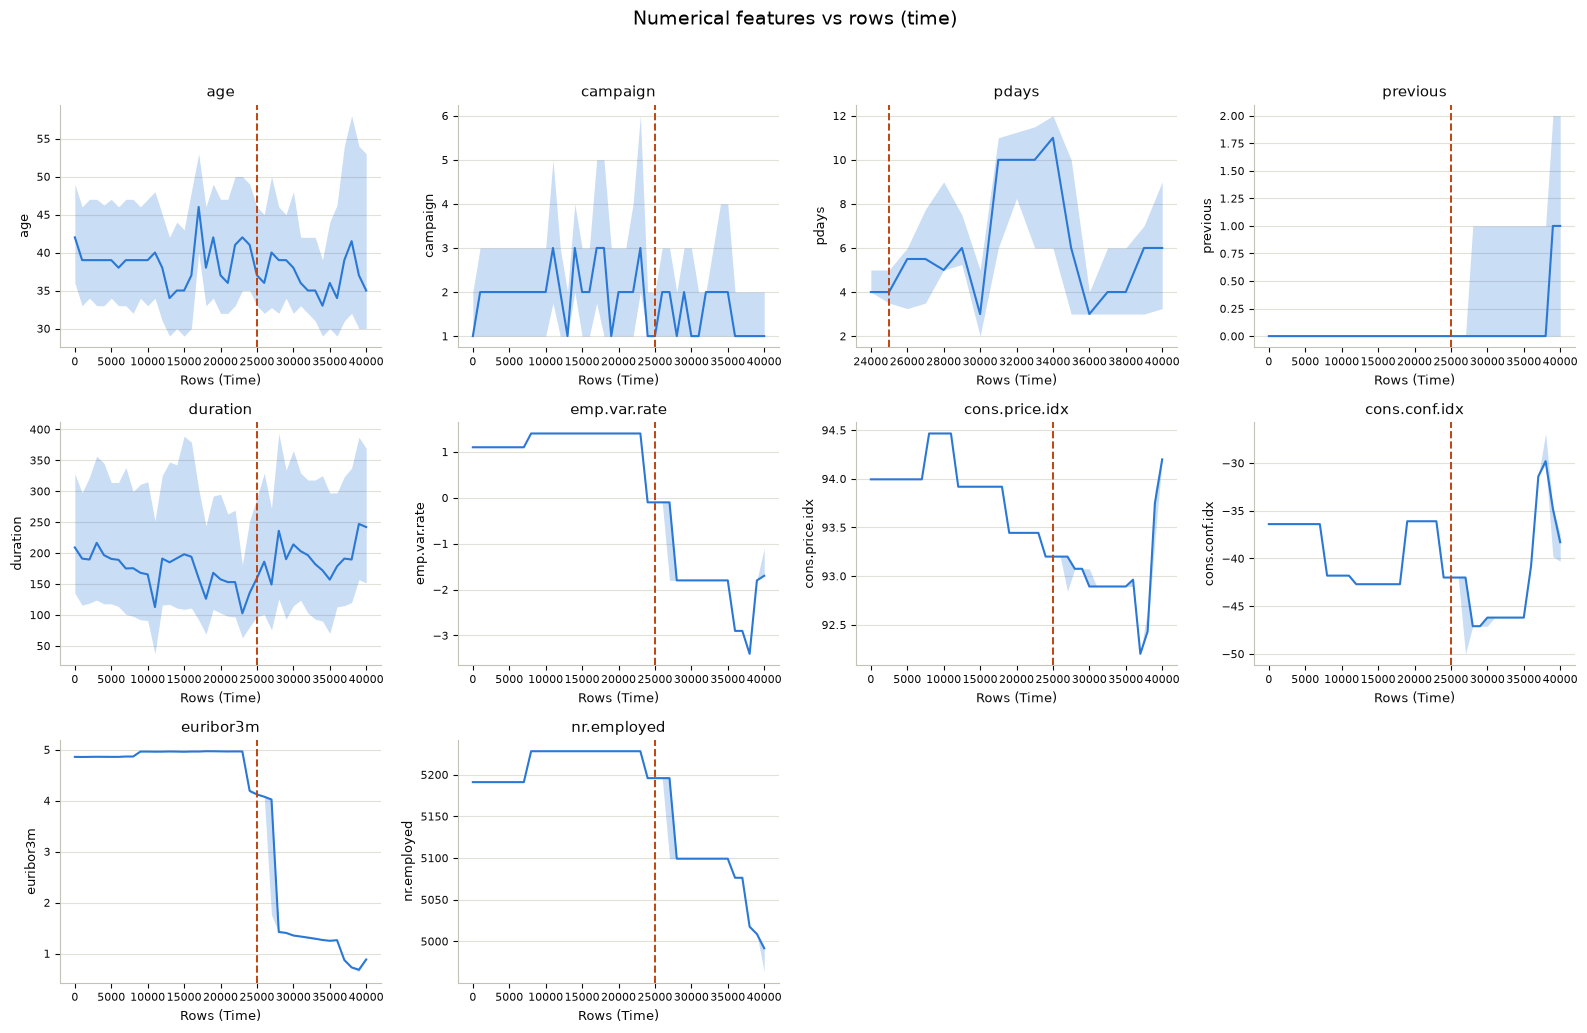

In [13]:
n_rows = n_cols = int(np.ceil(np.sqrt(len(NUMERICAL))))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()


block_id = np.arange(len(df)) // BLOCK
sizes = pd.Series(block_id).value_counts().sort_index()
keep = sizes[sizes >= BLOCK // 2].index          #drop the final block (188 rows)
x = keep.to_numpy() * BLOCK
for ax, col in zip(axes, NUMERICAL):
    q1, med, q3 = (df[col].groupby(block_id).quantile(q).loc[keep] for q in (0.25, 0.5, 0.75))
    ax.fill_between(x, q1, q3, color=BAR_COLOR, alpha=0.25, linewidth=0, zorder=2)
    ax.plot(x, med, color=BAR_COLOR, linewidth=1.5, zorder=3)
    ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
    ax.set_ylabel(col, fontsize=9, color="#0b0b0b")
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

#Remove any unused axes (if the grid has more cells than features).
for ax in axes[len(NUMERICAL):]:
    fig.delaxes(ax)

fig.suptitle("Numerical features vs rows (time)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

As for numerical data, some features exhibit a distinct change around the 25.000 rows mark. Most notably, this happens with the socio-economic features, excluding `cons.conf.idx` (it is not a surprise since they are all highly correlated between each other). As we already noticed, the campaign also started focusing on already contacted people, as we can see from `previous`.

### 3.5 Conclusions of EDA

We find that the dataset has a clear temporal structure which we cannot ignore. The first half of the dataset refers to the months May-August 2008 and is **not** representative of the whole dataset. The success rate then climbs in steps, 3% -> 6% -> 11% -> 45%, with the largest jump around row 36.000 (June 2010) rather than at the 25.000 mark. This strongly suggests that a rolling window approach, as suggested in the paper, is much more suited since it allows the models to learn what the most resent trend is: with a model trained only once, accuracy is progressively lost as time passes.

# 4. Comparison between different models

We now compare different ML models.

Four models: a **dummy**, **logistic regression**, **random forest** and **gradient
boosting**. Two things are varied:

- how the models are trained: only once or via a moving window;
- the five macro socio-economic features in or out.

The `duration` feature is included for benchmark resons only since it introduces leakage into the models.

The train/test split ratio is  80/20.

In [14]:
#Fix a seed and the number of splits to use
RANDOM_STATE = 42
NUMBER_OF_SPLITS = 10
#OneHotEncoder(handle_unknown="ignore") warns whenever a fold meets a level it was not
#trained on. Encoding it as all zeros is what we want, and the warning would otherwise be printed hundreds of times.
warnings.filterwarnings("ignore", message="Found unknown categories",
                        category=UserWarning)


def build_models(num, cat):
    """One pipeline per model. Each carries its own preprocessing:
    linear models want scaled numerics and one-hot categories. Trees want neither."""
    pre_linear = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", keep_empty_features=True)),
                          ("sc", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01,
                              drop="if_binary", sparse_output=False), cat),
    ])
    pre_tree = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", keep_empty_features=True), num),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat),
    ])
    return {
        "dummy":    Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
        "logistic": Pipeline([("pre", pre_linear),
                              ("clf", LogisticRegression(max_iter=5000,
                                                         random_state=RANDOM_STATE))]),
        "forest":   Pipeline([("pre", pre_tree),
                              ("clf", RandomForestClassifier(
                                  n_estimators=300, min_samples_leaf=5, n_jobs=-1,
                                  random_state=RANDOM_STATE))]),
        #HistGradientBoosting reads NaN natively, so nothing needs encoding.
        "boosting": Pipeline([("clf", HistGradientBoostingClassifier(
                                  categorical_features="from_dtype",
                                  random_state=RANDOM_STATE))]),
    }


def _fill_allnan_numeric(Xtr, Xte, num):
    """HistGradientBoosting's own binning step crashes when a numeric column is
    *entirely* missing within a training fold."""
    allnan = [c for c in num if Xtr[c].isna().all()]
    if allnan:
        Xtr, Xte = Xtr.copy(), Xte.copy()
        Xtr[allnan] = 0.0
        Xte[allnan] = 0.0
    return Xtr, Xte

## 4.1 Temporal split & feature set

We use as test set the **last** 20% of the dataset and `shuffle` stays False. As feature set we consider four variants, crossing the two feature questions:

|  | with the macro features | without |
|---|---|---|
| **with `duration`** | duration + macro | duration, no macro |
| **without `duration`** | with macro | neither |

**Only the bottom row can be deployed**: `duration` is the length of the call, so it does not
exist when we decide whether to make it. We keep the top row as a benchmark, to measure
what that feature was worth. We report ROC-AUC and AP/baseline.


In [15]:
DURATION = ["duration"]
CLIENT_NUM = [c for c in NUMERICAL if c not in ECONOMIC + DURATION]

FEATURE_SETS = {
	"duration + macro" : CLIENT_NUM + DURATION + ECONOMIC,  #benchmark only
	"duration, no macro" : CLIENT_NUM + DURATION,  #benchmark only
	"with macro" : CLIENT_NUM + ECONOMIC,  #deployable
	"neither" : CLIENT_NUM,  #deployable
}
DEPLOYABLE = ["with macro", "neither"]

df[CATEGORICAL] = df[CATEGORICAL].astype("category")
y_all = df[TARGET].eq("yes")
idx_work, idx_test = train_test_split(np.arange(len(df)), test_size=0.20, shuffle=False)
y_work, y_test = y_all.iloc[idx_work], y_all.iloc[idx_test]

cv = TimeSeriesSplit(n_splits=NUMBER_OF_SPLITS)

rows, curves = [], {}
for set_name, num in FEATURE_SETS.items() :
	X = df[num + CATEGORICAL].iloc[idx_work]
	for model_name, pipe in build_models(num, CATEGORICAL).items() :
		folds, roc, ap = [], [], []
		for tr, te in cv.split(X) :
			Xtr, Xte = _fill_allnan_numeric(X.iloc[tr], X.iloc[te], num)
			p = pipe.fit(Xtr, y_work.iloc[tr]).predict_proba(Xte)[:, 1]
			yt = y_work.iloc[te].to_numpy()
			folds.append((yt, p))
			roc.append(roc_auc_score(yt, p))
			ap.append(average_precision_score(yt, p) / yt.mean())
		curves[(set_name, model_name)] = folds
		rows.append({"features" : set_name, "model" : model_name,
		             "baseline" : np.mean([yt.mean() for yt, _ in folds]),
		             "ROC-AUC" : np.mean(roc), "roc sd" : np.std(roc, ddof=1),
		             "AP/baseline" : np.mean(ap), "AP/baseline sd" : np.std(ap, ddof=1)})

print(f"Training set {len(idx_work)} rows | test set {len(idx_test)} rows\n")
print(pd.DataFrame(rows).round(4).to_string(index=False))

Training set 32950 rows | test set 8238 rows

          features    model  baseline  ROC-AUC  roc sd  AP/baseline  AP/baseline sd
  duration + macro    dummy    0.0677   0.5000  0.0000       1.0000          0.0000
  duration + macro logistic    0.0677   0.8975  0.1160       8.7619          3.9954
  duration + macro   forest    0.0677   0.8802  0.1325       8.2727          3.7309
  duration + macro boosting    0.0677   0.9109  0.0916       7.9243          3.3943
duration, no macro    dummy    0.0677   0.5000  0.0000       1.0000          0.0000
duration, no macro logistic    0.0677   0.9160  0.0792       8.9896          3.8511
duration, no macro   forest    0.0677   0.9006  0.1104       8.4532          3.7164
duration, no macro boosting    0.0677   0.9088  0.0993       8.0288          3.4061
        with macro    dummy    0.0677   0.5000  0.0000       1.0000          0.0000
        with macro logistic    0.0677   0.5314  0.0970       1.2322          0.5095
        with macro   forest   

### ROC-AUC and LIFT curves

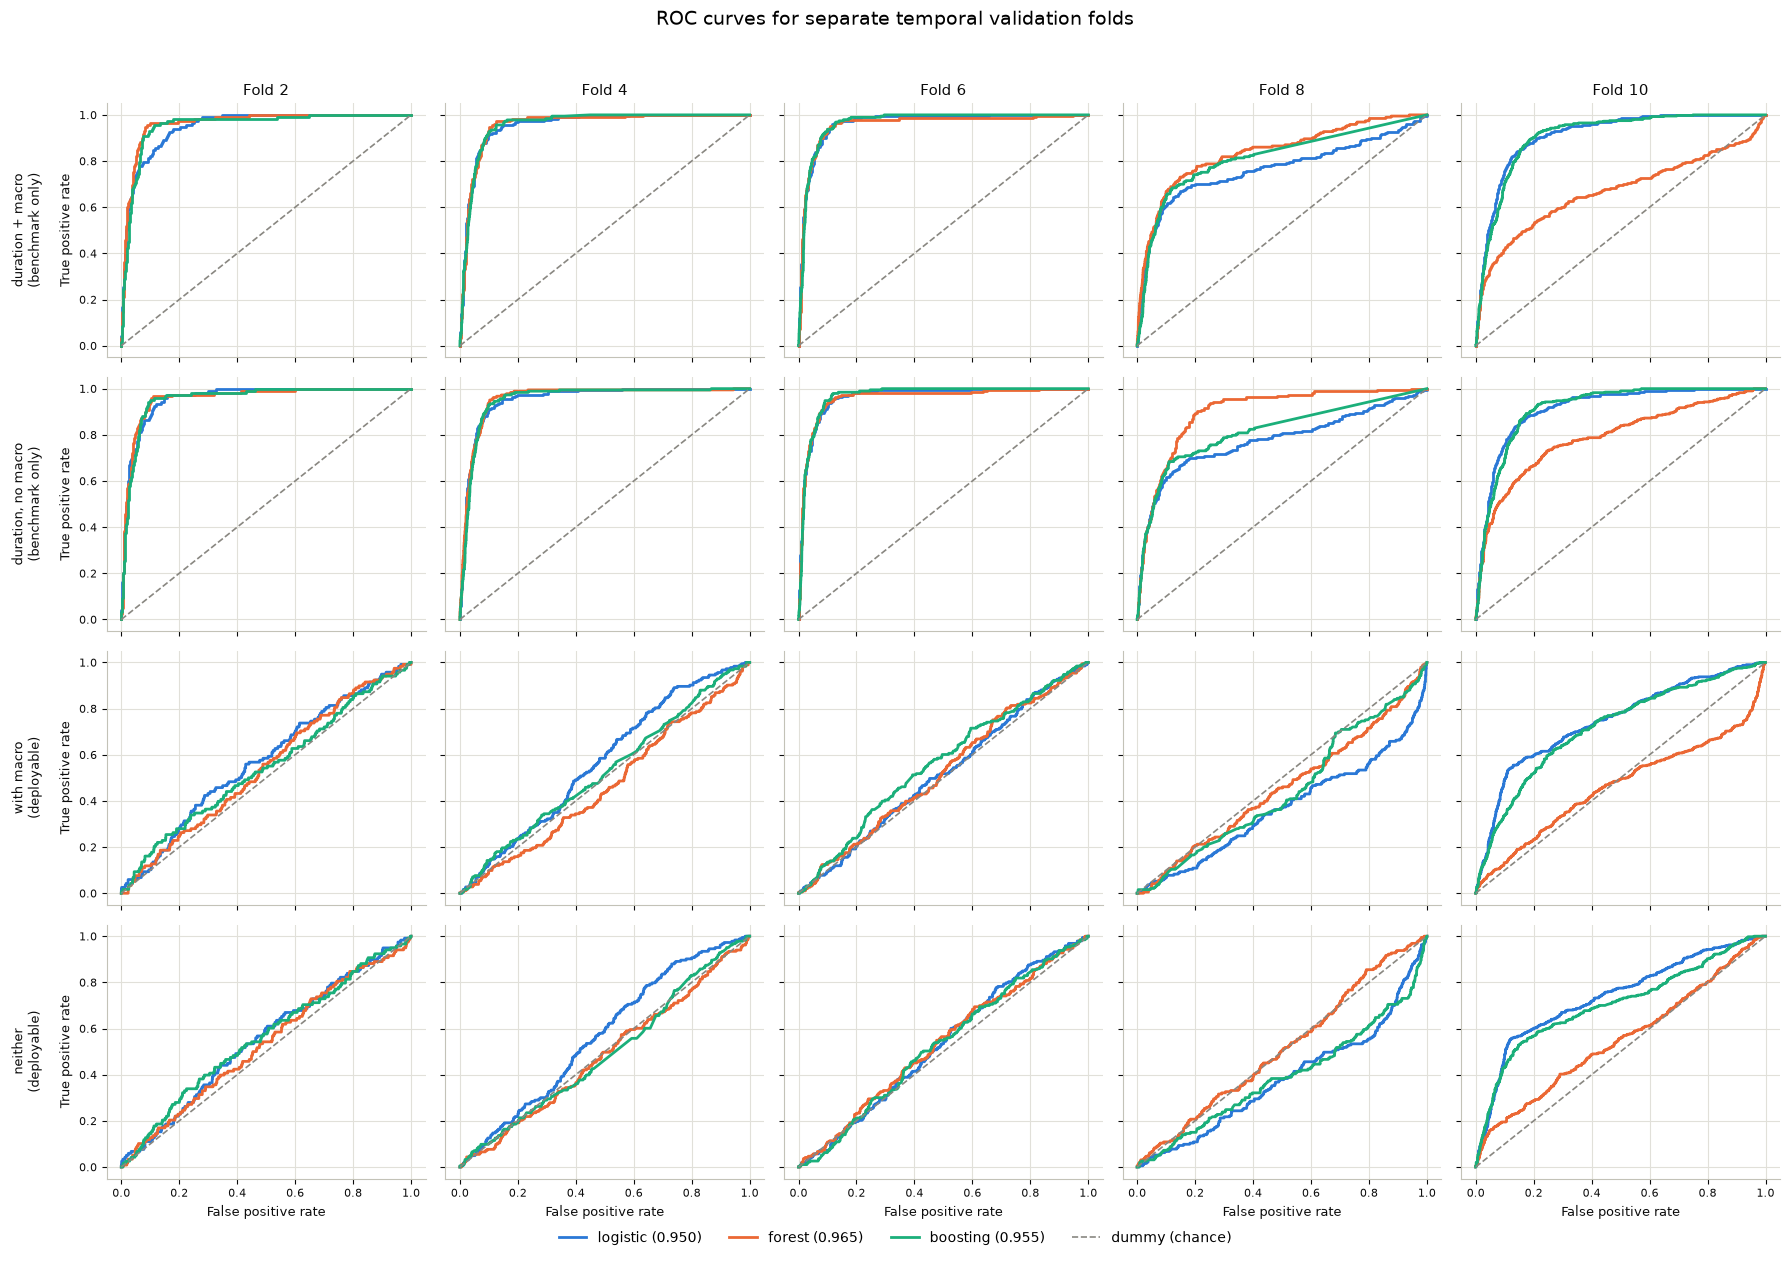

In [16]:
MODEL_COLORS = {
    "logistic": BAR_COLOR,
    "forest": "#eb6834",
    "boosting": "#1baf7a"
}
MODEL_ORDER = ["logistic", "forest", "boosting"]
SELECTED_FOLDS = [2, 4, 6, 8, 10]

fig, axes = plt.subplots(
    len(FEATURE_SETS),
    len(SELECTED_FOLDS),
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

for row, set_name in enumerate(FEATURE_SETS):
    for col, fold_number in enumerate(SELECTED_FOLDS):
        ax = axes[row, col]
        fold_index = fold_number - 1

        for model_name in MODEL_ORDER:
            yt, p = curves[(set_name, model_name)][fold_index]
            fpr, tpr, _ = roc_curve(yt, p)
            auc = roc_auc_score(yt, p)

            ax.plot(
                fpr,
                tpr,
                color=MODEL_COLORS[model_name],
                linewidth=2,
                label=f"{model_name} ({auc:.3f})"
            )

        ax.plot(
            [0, 1],
            [0, 1],
            color=QUANTILE_COLOR,
            linestyle="--",
            linewidth=1.2,
            label="dummy (chance)"
        )

        if row == 0:
            ax.set_title(f"Fold {fold_number}", fontsize=11, color=MEDIAN_COLOR)

        if col == 0:
            tag = "deployable" if set_name in DEPLOYABLE else "benchmark only"
            ax.set_ylabel(
                f"{set_name}\n({tag})\n\nTrue positive rate",
                fontsize=9,
                color=MEDIAN_COLOR
            )

        if row == len(FEATURE_SETS) - 1:
            ax.set_xlabel(
                "False positive rate",
                fontsize=9,
                color=MEDIAN_COLOR
            )

        ax.tick_params(labelsize=8, colors=MEDIAN_COLOR)
        ax.grid(color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)

        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(AXIS_COLOR)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "ROC curves for separate temporal validation folds",
    fontsize=14,
    y=1.02
)

fig.tight_layout()
plt.show()

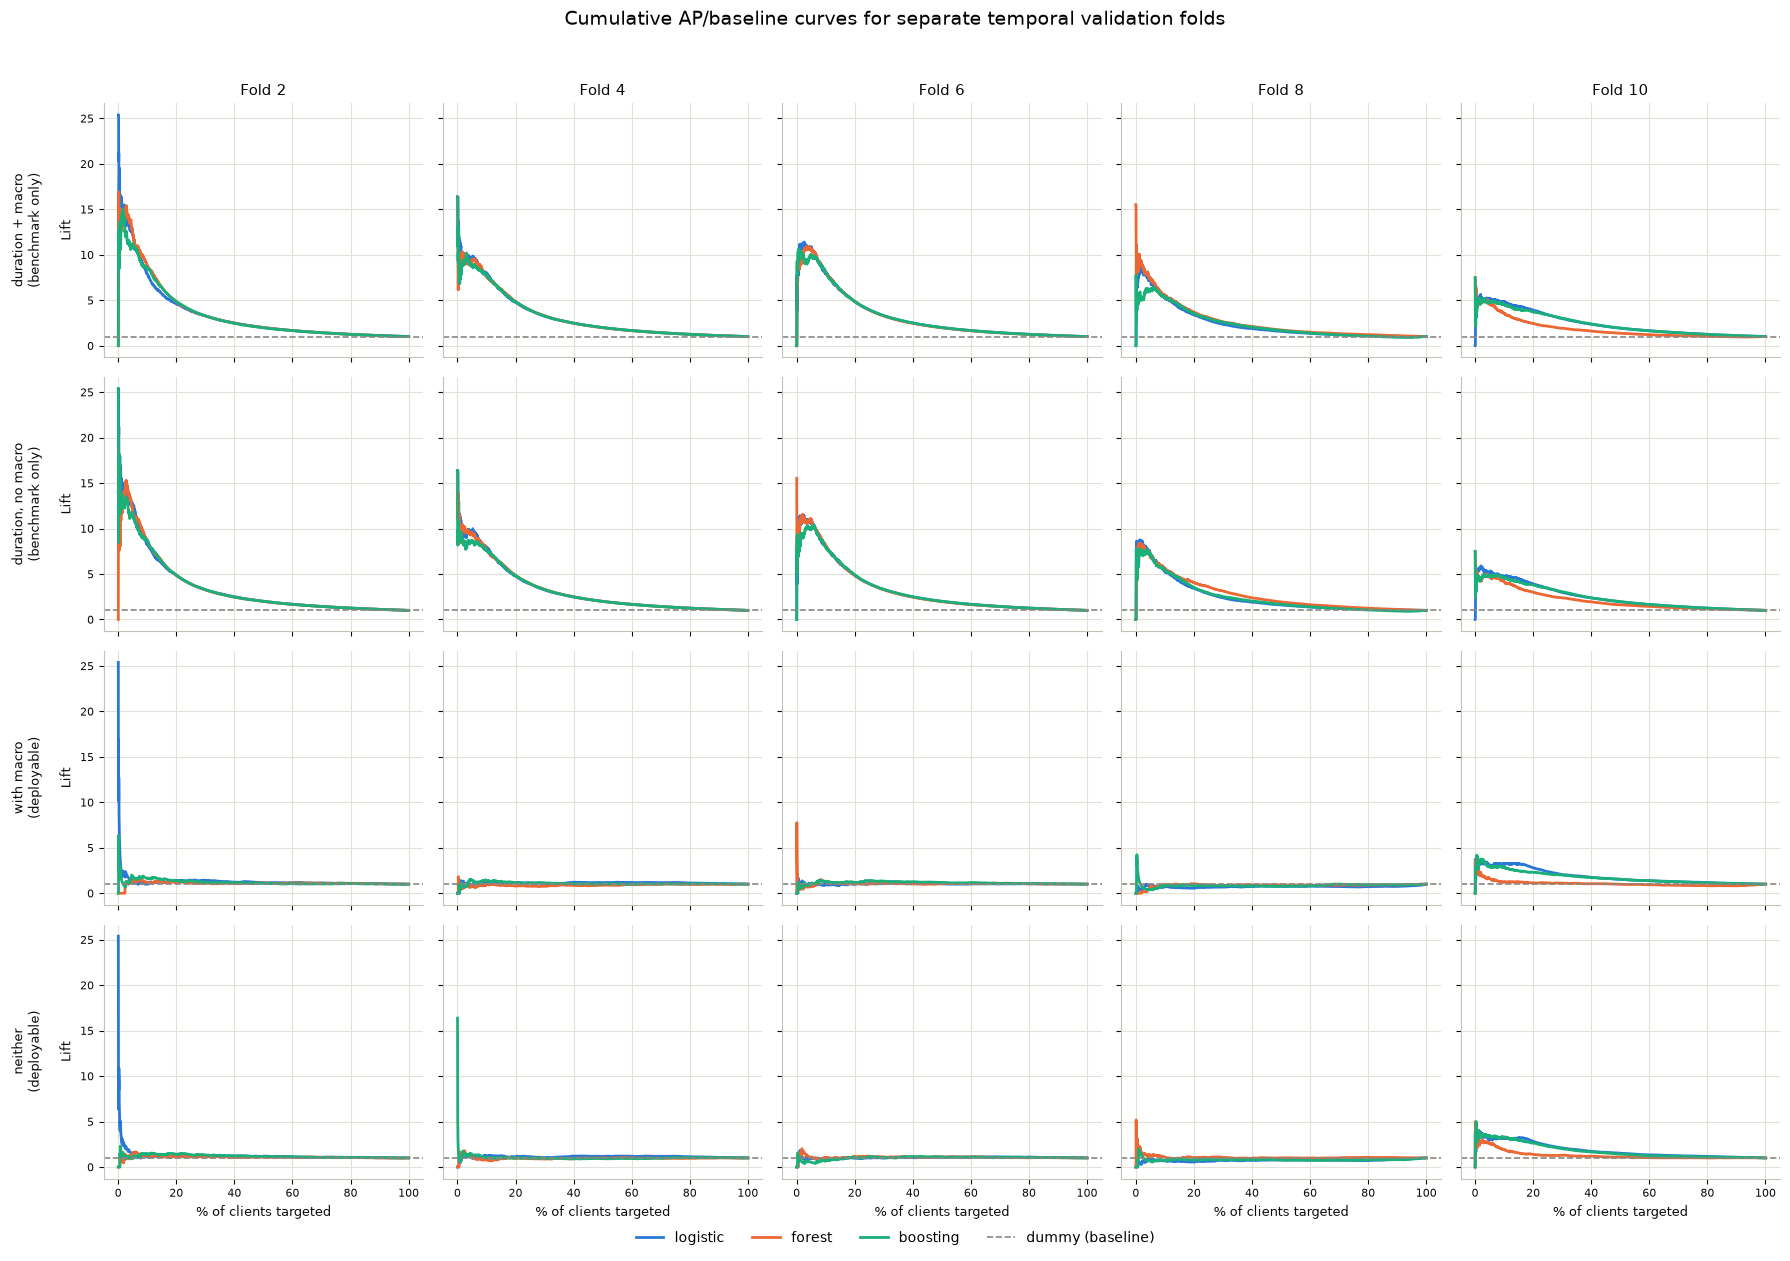

In [17]:
SELECTED_FOLDS = [2, 4, 6, 8, 10]

fig, axes = plt.subplots(
    len(FEATURE_SETS),
    len(SELECTED_FOLDS),
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

for row, set_name in enumerate(FEATURE_SETS):
    for col, fold_number in enumerate(SELECTED_FOLDS):
        ax = axes[row, col]
        fold_index = fold_number - 1

        for model_name in MODEL_ORDER:
            yt, p = curves[(set_name, model_name)][fold_index]

            order = np.argsort(-p)
            yt_sorted = np.asarray(yt)[order]

            n = len(yt_sorted)
            fraction = np.arange(1, n + 1) / n
            cumulative_rate = np.cumsum(yt_sorted)
            baseline = yt_sorted.mean() *np.arange(1, n + 1)

            ap_baseline = cumulative_rate / baseline

            ax.plot(
                fraction * 100,
                ap_baseline,
                color=MODEL_COLORS[model_name],
                linewidth=2,
                label=model_name
            )

        ax.axhline(
            1.0,
            color=QUANTILE_COLOR,
            linestyle="--",
            linewidth=1.2,
            label="dummy (baseline)"
        )

        if row == 0:
            ax.set_title(f"Fold {fold_number}", fontsize=11, color=MEDIAN_COLOR)

        if col == 0:
            tag = "deployable" if set_name in DEPLOYABLE else "benchmark only"
            ax.set_ylabel(
                f"{set_name}\n({tag})\n\nLift",
                fontsize=9,
                color=MEDIAN_COLOR
            )

        if row == len(FEATURE_SETS) - 1:
            ax.set_xlabel(
                "% of clients targeted",
                fontsize=9,
                color=MEDIAN_COLOR
            )

        ax.tick_params(labelsize=8, colors=MEDIAN_COLOR)
        ax.grid(color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)

        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(AXIS_COLOR)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Cumulative AP/baseline curves for separate temporal validation folds",
    fontsize=14,
    y=1.02
)

fig.tight_layout()
plt.show()

We see how the `duration` feature greatly improves the model, but also how, in initial folds, the models' performances are very lacking when not considering the `duration` of the call. In the initial regime, the provided features seem not to be informative about the success rate of a call.

In fold 10 instead we start seeing some signal, especially in ROC-AUC. We remark that the having 10 temporal folds on a 80/20 split implies that, when validating with the last fold, the models were trained with roughly the first 30.000 rows and predicts the next 3000. The models **see** the change of the statistics of successful calls, which we already saw starting at row ~25.000.

## 4.2 Rolling window

Sections 4.1 trains once on the first 80% of the file and then predicts the whole
remaining 20%, so by the end of the test set the model is 18 months old. That is not
how a campaign is actually run: a bank retrains as results come in. Moreover, the distant past should be neglected if there is an evolution in the statistics of the target variable.

The model is thus refitted **every 50 contacts** on a **rolling window of
the previous 5000 rows**, and each batch of 50 clients is scored by the model that
existed just before they were called. Older rows fall out of the window as new ones
arrive, so the training set tracks the campaign instead of accumulating it.

Two remarks:

- The window rolls over the test set as well. That is legitimate because
  those outcomes *are* known by then.
- **No grid search**. We stress this also in the final `Limitations` section.

The feature `duration` is excluded in both variants, since the models would not be deployable.

In [18]:
WINDOW, STEP = 5000, 50   #rows kept in the window, contacts between refits


def rolling_window_folds(num, model_name, window=WINDOW, step=STEP,
                         n_blocks=NUMBER_OF_SPLITS):
    """Rolling-window validation on the WORK set, returned in the same shape as 4.1.

    Every `step` rows the model is refitted on the previous `window` rows and used to
    score the next `step`, so each prediction comes from a model that only ever saw rows
    preceding that client. That gives one out-of-sample prediction per row rather than
    the ten validation blocks of 4.1, so the predictions are then cut into `n_blocks`
    contiguous blocks: those blocks are what we call folds here, and they are what the
    table and the grids below are computed on.
    """
    X = df[num + CATEGORICAL].iloc[idx_work]
    ys, ps = [], []
    for start in range(window, len(idx_work), step):
        tr = np.arange(start - window, start)
        te = np.arange(start, min(start + step, len(idx_work)))
        Xtr, Xte = _fill_allnan_numeric(X.iloc[tr], X.iloc[te], num)
        fitted = build_models(num, CATEGORICAL)[model_name].fit(Xtr, y_work.iloc[tr])
        ys.append(y_work.iloc[te].to_numpy())
        ps.append(fitted.predict_proba(Xte)[:, 1])
    y_oof, p_oof = np.concatenate(ys), np.concatenate(ps)
    return [(y_oof[b], p_oof[b])
            for b in np.array_split(np.arange(len(y_oof)), n_blocks)]


roll_rows, roll_curves = [], {}
for set_name in DEPLOYABLE:
    num = FEATURE_SETS[set_name]
    for model_name in build_models(num, CATEGORICAL):
        folds = rolling_window_folds(num, model_name)
        roc = [roc_auc_score(yt, p) for yt, p in folds]
        ap_baseline = [average_precision_score(yt, p) / yt.mean() for yt, p in folds]
        roll_curves[(set_name, model_name)] = folds
        roll_rows.append({"features": set_name, "model": model_name,
                          "baseline": np.mean([yt.mean() for yt, _ in folds]),
                          "ROC-AUC": np.mean(roc), "roc sd": np.std(roc, ddof=1),
                          "AP/baseline": np.mean(ap_baseline), "AP/baseline sd": np.std(ap_baseline, ddof=1)})
    print(f"done: {set_name}", flush=True)

n_refits = len(range(WINDOW, len(idx_work), STEP))
print(f"\nrolling window of {WINDOW} rows, refit every {STEP} contacts, "
      f"{n_refits} refits per model")
print(f"{len(idx_work) - WINDOW} of the {len(idx_work)} training rows are scored "
      f"out of sample, grouped into {NUMBER_OF_SPLITS} blocks\n")
print(pd.DataFrame(roll_rows).round(4).to_string(index=False))

done: with macro
done: neither

rolling window of 5000 rows, refit every 50 contacts, 559 refits per model
27950 of the 32950 training rows are scored out of sample, grouped into 10 blocks

  features    model  baseline  ROC-AUC  roc sd  AP/baseline  AP/baseline sd
with macro    dummy    0.0699   0.5000  0.0000       1.0000          0.0000
with macro logistic    0.0699   0.5651  0.0925       1.5434          0.8444
with macro   forest    0.0699   0.5719  0.1028       1.6052          0.8541
with macro boosting    0.0699   0.5662  0.0971       1.5412          0.6839
   neither    dummy    0.0699   0.5000  0.0000       1.0000          0.0000
   neither logistic    0.0699   0.5799  0.1001       1.6013          0.9965
   neither   forest    0.0699   0.5635  0.0947       1.4922          0.7275
   neither boosting    0.0699   0.5578  0.0890       1.4527          0.5967


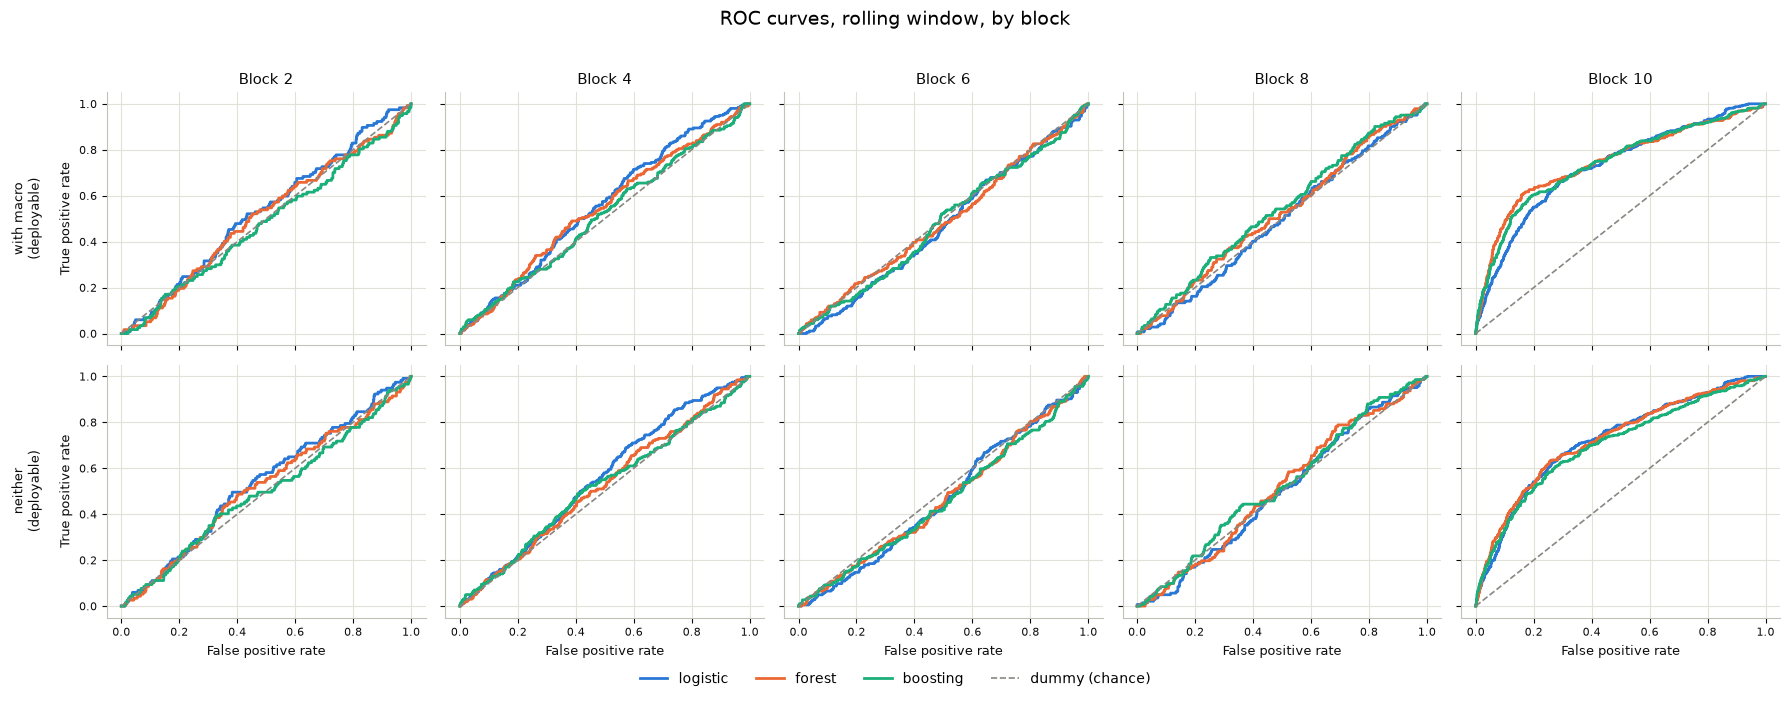

In [19]:
fig, axes = plt.subplots(len(DEPLOYABLE), len(SELECTED_FOLDS),
                         figsize=(18, 6.5), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, set_name in enumerate(DEPLOYABLE):
    for col, fold_number in enumerate(SELECTED_FOLDS):
        ax = axes[row, col]
        for model_name in MODEL_ORDER:
            yt, p = roll_curves[(set_name, model_name)][fold_number - 1]
            fpr, tpr, _ = roc_curve(yt, p)
            ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=2,
                    label=f"{model_name}")
        ax.plot([0, 1], [0, 1], color=QUANTILE_COLOR, linestyle="--", linewidth=1.2,
                label="dummy (chance)")

        if row == 0:
            ax.set_title(f"Block {fold_number}", fontsize=11, color=MEDIAN_COLOR)
        if col == 0:
            ax.set_ylabel(f"{set_name}\n(deployable)\n\nTrue positive rate",
                          fontsize=9, color=MEDIAN_COLOR)
        if row == len(DEPLOYABLE) - 1:
            ax.set_xlabel("False positive rate", fontsize=9, color=MEDIAN_COLOR)
        ax.tick_params(labelsize=8, colors=MEDIAN_COLOR)
        ax.grid(color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(AXIS_COLOR)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle("ROC curves, rolling window, by block", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

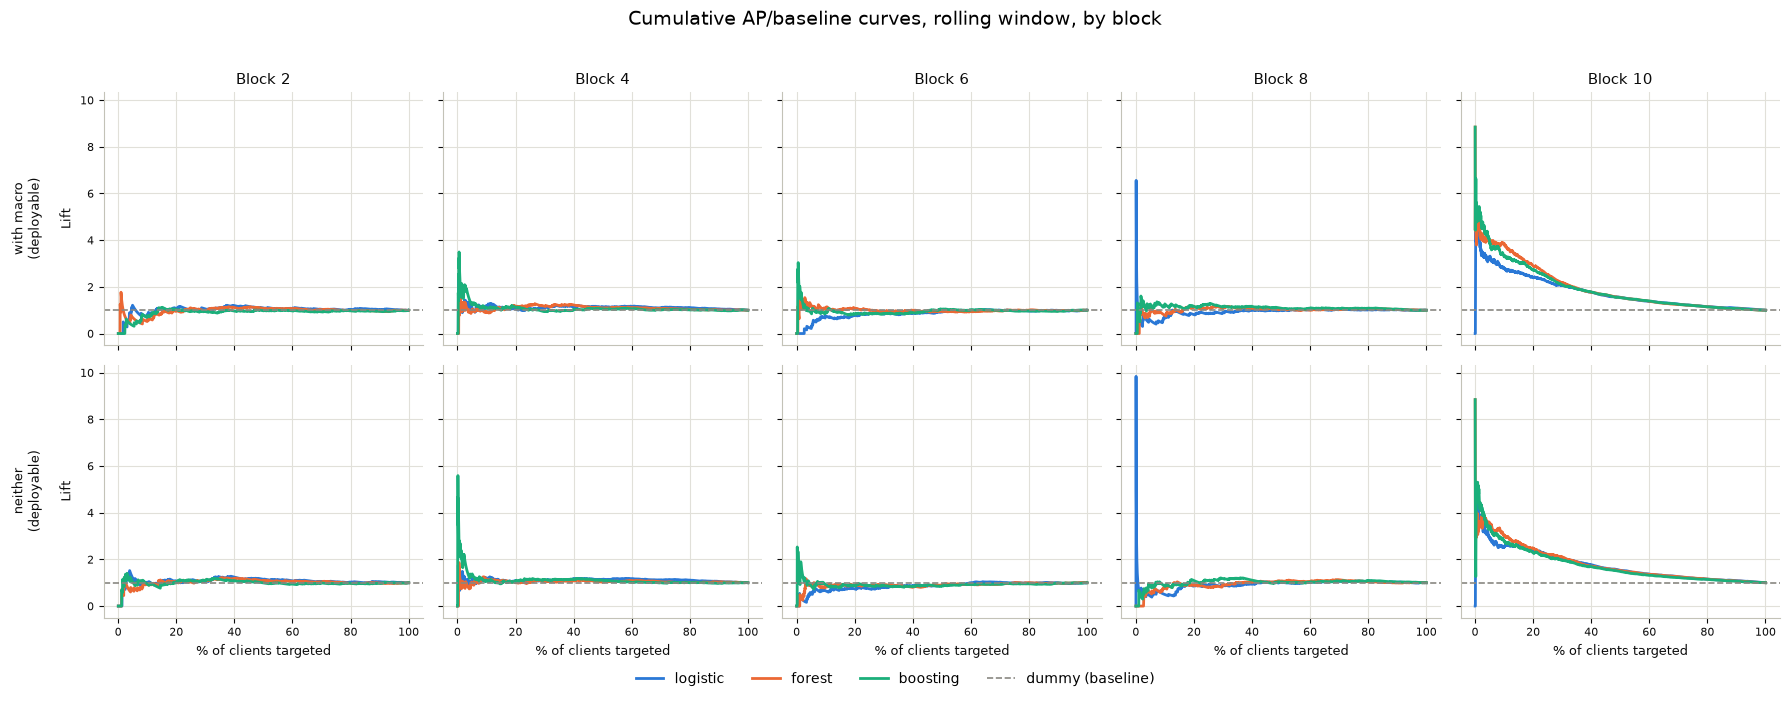

In [20]:
fig, axes = plt.subplots(len(DEPLOYABLE), len(SELECTED_FOLDS),
                         figsize=(18, 6.5), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, set_name in enumerate(DEPLOYABLE):
    for col, fold_number in enumerate(SELECTED_FOLDS):
        ax = axes[row, col]
        for model_name in MODEL_ORDER:
            yt, p = roll_curves[(set_name, model_name)][fold_number - 1]
            order = np.argsort(-p)
            yt_sorted = np.asarray(yt)[order]
            n = len(yt_sorted)
            fraction = np.arange(1, n + 1) / n
            ap_baseline = np.cumsum(yt_sorted) / (yt_sorted.mean() * np.arange(1, n + 1))
            ax.plot(fraction * 100, ap_baseline, color=MODEL_COLORS[model_name], linewidth=2,
                    label=model_name)
        ax.axhline(1.0, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2,
                   label="dummy (baseline)")

        if row == 0:
            ax.set_title(f"Block {fold_number}", fontsize=11, color=MEDIAN_COLOR)
        if col == 0:
            ax.set_ylabel(f"{set_name}\n(deployable)\n\nLift", fontsize=9,
                          color=MEDIAN_COLOR)
        if row == len(DEPLOYABLE) - 1:
            ax.set_xlabel("% of clients targeted", fontsize=9, color=MEDIAN_COLOR)
        ax.tick_params(labelsize=8, colors=MEDIAN_COLOR)
        ax.grid(color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(AXIS_COLOR)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Cumulative AP/baseline curves, rolling window, by block", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4.3 The same comparison, with random folds

Sections 4.1 and 4.2 both respect the order of the file. This
section runs **exactly the grid of 4.1**: same four feature sets, same four models, same ten
folds, replacing `TimeSeriesSplit` with `StratifiedKFold(shuffle=True)`, so that the only
difference between the two tables is how the folds are drawn.

This is the cell that settles the question asked at the start.

In [21]:
#Same grid as 4.1, only the fold generator changes: the rows are shuffled before splitting,
#so every fold is trained on rows that come both before and after the rows it predicts.
random_cv = StratifiedKFold(NUMBER_OF_SPLITS, shuffle=True, random_state=RANDOM_STATE)

random_rows = []
for set_name, num in FEATURE_SETS.items() :
	X = df[num + CATEGORICAL].iloc[idx_work]
	for model_name, pipe in build_models(num, CATEGORICAL).items() :
		roc, ap_baseline = [], []
		for tr, te in random_cv.split(X, y_work) :
			p = pipe.fit(X.iloc[tr], y_work.iloc[tr]).predict_proba(X.iloc[te])[:, 1]
			yt = y_work.iloc[te].to_numpy()
			roc.append(roc_auc_score(yt, p))
			ap_baseline.append(average_precision_score(yt, p) / yt.mean())
		random_rows.append({"features" : set_name, "model" : model_name,
		                    "baseline" : y_work.mean(),
		                    "ROC-AUC" : np.mean(roc), "roc sd" : np.std(roc, ddof=1),
		                    "AP/baseline" : np.mean(ap_baseline), "AP/baseline sd" : np.std(ap_baseline, ddof=1)})
	print(f"done: {set_name}", flush=True)

print(f"\nRandom {NUMBER_OF_SPLITS}-fold cross validation\n")
print(pd.DataFrame(random_rows).round(4).to_string(index=False))

#What adding the five macro features is worth, under the two fold generators.
#`rows` is the table built in 4.1 with the temporal folds.
rnd = pd.DataFrame(random_rows).set_index(["features", "model"])["ROC-AUC"]
tmp = pd.DataFrame(rows).set_index(["features", "model"])["ROC-AUC"]

print("\nChange in ROC-AUC when the five macro features are ADDED\n")
print(f"{'':>15} {'model':>9} {'random folds':>14} {'temporal folds':>16}")
for with_m, without_m, tag in [("with macro", "neither", "no duration"),
                               ("duration + macro", "duration, no macro", "with duration")] :
	for m in ("logistic", "forest", "boosting") :
		print(f"{tag:>15} {m:>9} {rnd[(with_m, m)] - rnd[(without_m, m)]:>+14.4f}"
		      f" {tmp[(with_m, m)] - tmp[(without_m, m)]:>+16.4f}")

done: duration + macro
done: duration, no macro
done: with macro
done: neither

Random 10-fold cross validation

          features    model  baseline  ROC-AUC  roc sd  AP/baseline  AP/baseline sd
  duration + macro    dummy    0.0637   0.5000  0.0000       1.0000          0.0000
  duration + macro logistic    0.0637   0.9457  0.0081       7.9847          0.5796
  duration + macro   forest    0.0637   0.9553  0.0078       8.9022          0.6490
  duration + macro boosting    0.0637   0.9575  0.0056       8.9403          0.5796
duration, no macro    dummy    0.0637   0.5000  0.0000       1.0000          0.0000
duration, no macro logistic    0.0637   0.9426  0.0082       7.9055          0.5814
duration, no macro   forest    0.0637   0.9500  0.0072       8.0170          0.7221
duration, no macro boosting    0.0637   0.9532  0.0054       8.4436          0.4843
        with macro    dummy    0.0637   0.5000  0.0000       1.0000          0.0000
        with macro logistic    0.0637   0.6728 

With random folds all six comparisons are positive (+0.003 to +0.012). With temporal folds the same features are worth practically **nothing**, random noise.

The reason is visible in the EDA: the five macro features are functions of calendar time. They identify *when* a call was made. Under a shuffled split the fold that predicts a row has also been trained on its neighbours, so this amounts to handing the model the local base rate, which moves from 3% to 45% across the file. Under a temporal split the model has to *extrapolate* that clock past the end of its training data, where it has never been, and the macro coefficients it fitted no longer apply.

This does not contradict the paper. There the macro features are used with others we do
not have: call direction, agent experience, the rate offered etc.

## 4.4 The test set

We choose to use the logistic regression as the final model on the test set. It performs better than the others on the single training case, while with the rolling window approach all three are more or less equivalent: the logistic is chosen for its simplicity and since it is fast to train.

The delivered model is the logistic regression on both the **with macro** feature set (client
features plus the five socio-economic indicators, `duration` excluded) and on the feature set **without macros** (and duration). It is also reported with
`duration` added, which we repeat cannot be deployed and is shown only to price that feature. We use a rolling window approach as in the previous section.

We plot the ROC and the cumulative LIFT curve.

In [22]:
# 4.4 Final test-set evaluation (rolling window only).
#
# We evaluate only the deployable logistic models:
# - client features plus the five macro socio-economic indicators;
# - client features only.
#
# Both are trained with the rolling-window protocol used in Section 4.2:
# a model is refitted every STEP contacts on the previous WINDOW contacts,
# and each batch of STEP clients is scored by the model that existed just
# before they were called.

FINAL_MODEL = "logistic"

FINAL_MODELS = {
    "Macro + client features": ("with macro", FINAL_MODEL),
    "Client features only": ("neither", FINAL_MODEL),
	"Duration + macro": ("duration + macro", FINAL_MODEL),
}


def rolling_window_test(num, model_name, window=WINDOW, step=STEP):
    """
    Predict the chronological test set with a rolling-window procedure.
    """
    X = df[num + CATEGORICAL]
    ys, ps = [], []

    for start in range(0, len(idx_test), step):
        stop = min(start + step, len(idx_test))

        first_test_row = idx_test[start]
        tr = np.arange(max(0, first_test_row - window), first_test_row)
        te = idx_test[start:stop]

        Xtr, Xte = _fill_allnan_numeric(
            X.iloc[tr],
            X.iloc[te],
            num
        )

        fitted = build_models(num, CATEGORICAL)[model_name].fit(
            Xtr,
            y_all.iloc[tr]
        )

        ys.append(y_all.iloc[te].to_numpy())
        ps.append(fitted.predict_proba(Xte)[:, 1])

    return np.concatenate(ys), np.concatenate(ps)


final_rows = []
final_p = {}

for label, (set_name, model_name) in FINAL_MODELS.items():
    num = FEATURE_SETS[set_name]

    yt_test, p = rolling_window_test(num, model_name)

    final_p[label] = p

    baseline_test = yt_test.mean()
    order = np.argsort(-p)
    top10 = max(1, int(np.ceil(0.10 * len(yt_test))))

    final_rows.append({
        "model": label,
        "baseline": baseline_test,
        "ROC-AUC": roc_auc_score(yt_test, p),
        "AP/baseline": average_precision_score(yt_test, p) / baseline_test,
        "Lift at 10%": yt_test[order[:top10]].mean() / baseline_test,
    })

final_results = pd.DataFrame(final_rows)

Test set: 8238 contacts. Rolling window: 5000 previous contacts, refitted every 50 contacts.
                  model  baseline  ROC-AUC  AP/baseline  Lift at 10%
Macro + client features    0.3083   0.7647       1.9057       2.3341
   Client features only    0.3083   0.7633       1.9119       2.3341
       Duration + macro    0.3083   0.8433       2.1090       2.4128


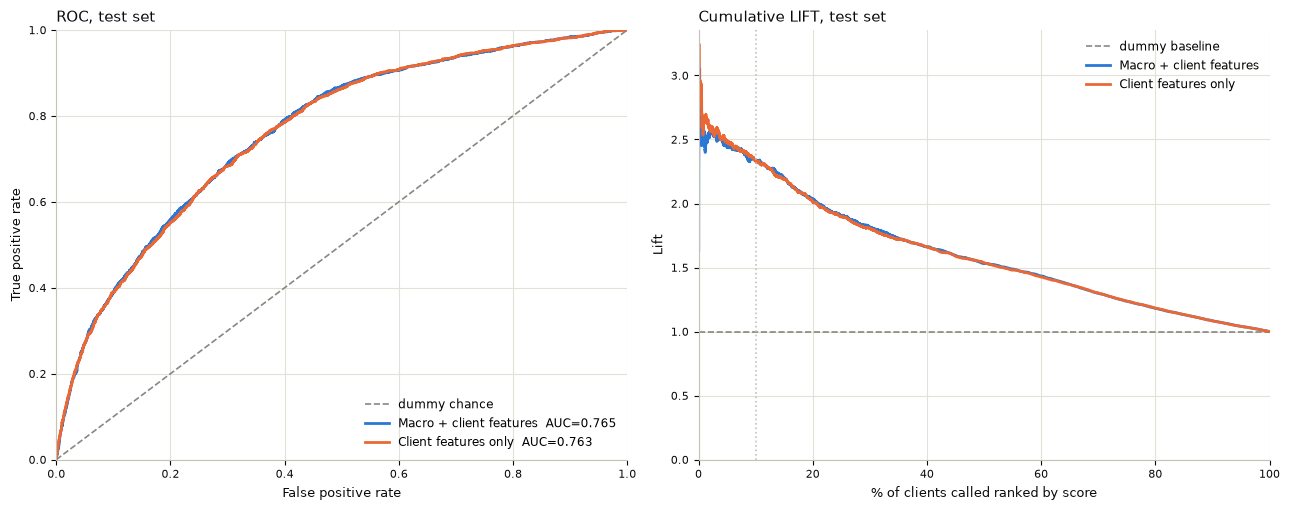

In [23]:
# Results, ROC and LIFT

print(
    f"Test set: {len(y_test)} contacts. "
    f"Rolling window: {WINDOW} previous contacts, "
    f"refitted every {STEP} contacts."
)

print(final_results.round(4).to_string(index=False))


CURVE_COLORS = {
    "Macro + client features": BAR_COLOR,
    "Client features only": "#eb6834",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# ROC curves.
ax = axes[0]

ax.plot(
    [0, 1],
    [0, 1],
    color=QUANTILE_COLOR,
    linestyle="--",
    linewidth=1.2,
    label="dummy chance"
)

for label, color in CURVE_COLORS.items():
    p = final_p[label]
    fpr, tpr, _ = roc_curve(y_test, p)

    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{label}  AUC={roc_auc_score(y_test, p):.3f}"
    )

ax.set_xlabel(
    "False positive rate",
    fontsize=9,
    color=MEDIAN_COLOR
)

ax.set_ylabel(
    "True positive rate",
    fontsize=9,
    color=MEDIAN_COLOR
)

ax.set_title(
    "ROC, test set",
    fontsize=11,
    loc="left",
    color=MEDIAN_COLOR
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


# Cumulative LIFT curves.
ax = axes[1]

baseline_test = y_test.mean()

ax.axhline(
    1.0,
    color=QUANTILE_COLOR,
    linestyle="--",
    linewidth=1.2,
    label="dummy baseline"
)

for label, color in CURVE_COLORS.items():
    p = final_p[label]

    order = np.argsort(-p)
    cumulative_rate = (
        np.cumsum(y_test.to_numpy()[order])
        / np.arange(1, len(y_test) + 1)
    )

    fraction = np.arange(1, len(y_test) + 1) / len(y_test)

    ax.plot(
        100 * fraction,
        cumulative_rate / baseline_test,
        color=color,
        linewidth=2,
        label=label
    )

ax.axvline(
    10,
    color=AXIS_COLOR,
    linestyle=":",
    linewidth=1.2
)

ax.set_xlabel(
    "% of clients called ranked by score",
    fontsize=9,
    color=MEDIAN_COLOR
)

ax.set_ylabel(
    "Lift",
    fontsize=9,
    color=MEDIAN_COLOR
)

ax.set_title(
    "Cumulative LIFT, test set",
    fontsize=11,
    loc="left",
    color=MEDIAN_COLOR
)

ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)


# Common plot styling.
for ax in axes:
    ax.legend(
        frameon=False,
        fontsize=8.5
    )

    ax.tick_params(
        labelsize=8,
        colors=MEDIAN_COLOR
    )

    ax.grid(
        color=GRID_COLOR,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(AXIS_COLOR)

fig.tight_layout()
plt.show()

# 5. Conclusions

In [24]:
#Every number the conclusions below rest on, for the logistic regression only, collected
#from the four tables already computed above. Nothing is refitted here:
#  rows          -> 4.1  temporal 10-fold over the first 80%, one fit per fold
#  roll_rows     -> 4.2  same rows and same blocks, refit every STEP on the previous WINDOW
#  random_rows   -> 4.3  random 10-fold over all rows
#  final_rows    -> 4.4  held-out last 20%, rolling window
#Empty cells are combinations that were never run: 4.2 was restricted to the deployable
#feature sets, and 4.4 to the three models actually delivered.

SET_ORDER = ["duration + macro", "duration, no macro", "with macro", "neither"]
#4.4 is keyed by a display label instead of a feature-set name: invert FINAL_MODELS.
TEST_LABEL = {set_name: label for label, (set_name, _) in FINAL_MODELS.items()}

#Named, so that reordering PROTOCOLS can never silently change which pair is subtracted.
P41 = "4.1  temporal 10-fold      (first 80%)"
P42 = "4.2  temporal rolling win. (first 80%)"
P43 = "4.3  random 10-fold        (first 80%)"
P44 = "4.4  rolling window, TEST  (last 20%)"

PROTOCOLS = [
    (P41, rows, "cv"),
    (P42, roll_rows, "cv"),
    (P43, random_rows, "cv"),
    (P44, final_rows, "test"),
]

summary = []
for protocol, table, kind in PROTOCOLS:
    for set_name in SET_ORDER:
       if kind == "cv":
          hit = [r for r in table
                 if r["features"] == set_name and r["model"] == FINAL_MODEL]
       else:
          hit = [r for r in table if r["model"] == TEST_LABEL.get(set_name)]
       if not hit:
          continue
       r = hit[0]
       summary.append({"protocol": protocol, "features": set_name,
                       "baseline": r["baseline"], "ROC-AUC": r["ROC-AUC"],
                       "roc sd": r.get("roc sd", np.nan), "AP/baseline": r["AP/baseline"]})

summary = pd.DataFrame(summary)

print(f"Logistic regression only. Rolling window = {WINDOW} rows, refit every {STEP} "
      f"contacts.\n{len(summary)} of the {len(PROTOCOLS) * len(SET_ORDER)} "
      f"(protocol x feature set) combinations were run.\n")
hdr = f"{'protocol':>38} {'features':>19} {'baseline':>9} {'ROC-AUC':>9} {'sd':>7} {'AP/baseline':>6}"
print(hdr)
print("-" * len(hdr))
current = None
for _, r in summary.iterrows():
    if r["protocol"] != current:
       if current is not None:
          print()
       current = r["protocol"]
    sd = "      -" if pd.isna(r["roc sd"]) else f"{r['roc sd']:>7.3f}"
    print(f"{r['protocol']:>38} {r['features']:>19} {r['baseline']:>9.3f} "
          f"{r['ROC-AUC']:>9.4f} {sd} {r['AP/baseline']:>6.2f}")

#--- the three claims of Section 5, as differences ----------------------------------
A = summary.set_index(["protocol", "features"])


def delta(protocol, plus, minus, column):
    """Value of `plus` minus value of `minus`, or None if either was not run."""
    if (protocol, plus) in A.index and (protocol, minus) in A.index:
       return A.loc[(protocol, plus), column] - A.loc[(protocol, minus), column]
    return None


def block(title, pairs):
    """One line per comparison, ROC-AUC and AP/baseline side by side."""
    print(f"\n{title}")
    print(f"  {'':>38}  {'':<16} {'ROC-AUC':>9} {'AP/baseline':>8}")
    for protocol, _, _ in PROTOCOLS:
       for plus, minus, tag in pairs:
          d_roc = delta(protocol, plus, minus, "ROC-AUC")
          if d_roc is None:
             continue
          d_ap_baseline = delta(protocol, plus, minus, "AP/baseline")
          print(f"  {protocol:>38}  {tag:<16} {d_roc:>+9.4f} {d_ap_baseline:>+8.3f}")


Logistic regression only. Rolling window = 5000 rows, refit every 50 contacts.
13 of the 16 (protocol x feature set) combinations were run.

                              protocol            features  baseline   ROC-AUC      sd AP/baseline
--------------------------------------------------------------------------------------------------
4.1  temporal 10-fold      (first 80%)    duration + macro     0.068    0.8975   0.116   8.76
4.1  temporal 10-fold      (first 80%)  duration, no macro     0.068    0.9160   0.079   8.99
4.1  temporal 10-fold      (first 80%)          with macro     0.068    0.5314   0.097   1.23
4.1  temporal 10-fold      (first 80%)             neither     0.068    0.5433   0.100   1.29

4.2  temporal rolling win. (first 80%)          with macro     0.070    0.5651   0.092   1.54
4.2  temporal rolling win. (first 80%)             neither     0.070    0.5799   0.100   1.60

4.3  random 10-fold        (first 80%)    duration + macro     0.064    0.9457   0.008   7.98
4

We show how much each feature is worth, by subtracting the value obtained without the feature from the value obtained with it.

In [25]:

block("(1) what the five MACRO features are worth",
      [("with macro", "neither", "no duration"),
       ("duration + macro", "duration, no macro", "with duration")])

block("(2) what DURATION is worth",
      [("duration + macro", "with macro", "keeping macro"),
       ("duration, no macro", "neither", "dropping macro")])

print("\n(3) what ROLLING-WINDOW RETRAINING is worth  (4.2 minus 4.1, identical rows, different training)")
print(f"  {'':>38}  {'':<16} {'ROC-AUC':>9} {'AP/baseline':>8}")
for set_name in DEPLOYABLE:
    d_roc = A.loc[(P42, set_name), "ROC-AUC"] - A.loc[(P41, set_name), "ROC-AUC"]
    d_ap_baseline = A.loc[(P42, set_name), "AP/baseline"] - A.loc[(P41, set_name), "AP/baseline"]
    print(f"  {P42:>38}  {set_name:<16} {d_roc:>+9.4f} {d_ap_baseline:>+8.3f}")

print("\nThe four protocols are NOT comparable with one another: they score different rows.\n"
      "Read each block down a single protocol, never across two. The AP/baseline column in\n"
      "particular is average precision over the base rate, so it is only meaningful\n"
      "between two rows that share a baseline.")


(1) what the five MACRO features are worth
                                                             ROC-AUC AP/baseline
  4.1  temporal 10-fold      (first 80%)  no duration        -0.0119   -0.061
  4.1  temporal 10-fold      (first 80%)  with duration      -0.0185   -0.228
  4.2  temporal rolling win. (first 80%)  no duration        -0.0148   -0.058
  4.3  random 10-fold        (first 80%)  no duration        +0.0046   +0.117
  4.3  random 10-fold        (first 80%)  with duration      +0.0031   +0.079
   4.4  rolling window, TEST  (last 20%)  no duration        +0.0014   -0.006

(2) what DURATION is worth
                                                             ROC-AUC AP/baseline
  4.1  temporal 10-fold      (first 80%)  keeping macro      +0.3661   +7.530
  4.1  temporal 10-fold      (first 80%)  dropping macro     +0.3727   +7.696
  4.3  random 10-fold        (first 80%)  keeping macro      +0.2730   +4.715
  4.3  random 10-fold        (first 80%)  dropping macro     +0.

**On the question we set out to answer.** The five macro socio-economic features **do not
improve** the prediction of telemarketing success once the validation respects the order of the
file. With both random folds and temporal folds they give a small difference, of ~0.01 at most.

**On `duration`.** It is worth about **+0.08 ROC-AUC** on the test set (0.8433 against 0.7647)
and far more in cross validation, where the difference is +0.27 (with random splits) and +0.37 (with temporal splits).

**It cannot be deployed**: it is the length of the call, and it does not exist at the moment the
decision to place the call is taken.

**On retraining.** The rolling window is the only change that improved a deployable model.
On the same training rows and the same blocks, without considering macros **refitting every 50 contacts on the previous 5000 moves the logistic regression from ROC-AUC 0.5433 to 0.5799 and its AP/baseline from 1.29 to 1.60**. On the test set it reaches ROC-AUC 0.765 and lift 2.3 in the top decile, i.e. contacting the best-scored 10% of clients finds 2.3 times as many subscribers as contacting 10% at random.

**On model choice.** Within any single setting, logistic regression, random forest and
gradient boosting land within ~0.02 ROC-AUC of each other; **the choice of validation scheme
moves the result more than the choice of model family**. We deliver the logistic
regression: it is the cheapest to refit.

**A caveat on reading the numbers.** The test-set figures are not comparable with the
cross-validation figures . The test set is the last 20% of the file, which is the late
regime, totally different from the initial one of the training set. **A single number for "the performance of the model" does not exist on this dataset; it depends entirely on which period is being scored**.

# 6. Limitations

- **The dataset is incomplete and misses key features.** It is a public subset of the data
  behind Moro, Cortez & Rita (2014): 41.188 of their 52.944 contacts, ending in November 2010
  instead of June 2013. Key features are missing. Everything about the interest rate offered, the agent, the call context and the bank's internal client profiling is absent. Nothing here can be read as a
  replication.

- **The dataset covers several operating regimes and the models do not transfer between
  them.**

- **No hyperparameter was tuned.** All three models run at their defaults (plus
  `min_samples_leaf=5` and `n_estimators=300` for the forest). A grid search inside each
  temporal fold would be the correct thing to do and was skipped for runtime.

- **The window length and the refit step were not optimised.** `WINDOW = 5000` and
  `STEP = 50` were fixed a priori. The paper uses 20.000 and 10 on a larger file.

- **A single seed.** `RANDOM_STATE = 42` throughout.